"""
================================================================================
ENTRENAMIENTO DESDE CERO V9: RED NEURONAL INFORMADA POR LA FÍSICA PARETO-OPTIMAL
================================================================================

Este script contiene la versión V9 adaptada de forma agnóstica a N bases para 
romper el dilema de compromiso de Pareto. Rescata simultáneamente:
  1. El ajuste preciso de la Curva Límite en todo el dominio continuo.
  2. El desacoplamiento paramétrico exacto de las Bases Puras (extinción de crosstalk).

Estrategias avanzadas aplicadas en la Versión V9 "Pareto-Optimal":
  1. LAYER NORMALIZATION: Reemplaza Batch Normalization. Normaliza cada muestra de forma 
     individual e independiente. Estabiliza el gradiente de escala exponencial para la
     Curva Límite sin promediar estadísticas entre muestras, preservando intactos los 
     codos (hinges) y la identidad dispersa de las bases puras.
  2. PÉRDIDA DE CROSSTALK INTELIGENTE (SPARSITY LOSS): Introduce una máscara dinámica
     basada en la matriz de coeficientes objetivo. Si el coeficiente teórico es cero 
     (bases puras), se aplica una penalización paramétrica para extinguir las fugas de masa.
     Si la combinación es densa (curva límite/híbrida), la máscara libera la restricción 
     para dar flexibilidad al ajuste de amplitudes altas.
  3. ARQUITECTURA DINÁMICA (N BASES): Detección e inferencia automática del número de 
     bases N presentes en la matriz A y el dataset, eliminando cualquier dependencia de
     dimensiones fijas (hardcoded).
  4. BALANCED DATASET: Manejo balanceado de muestras para garantizar suficiente densidad 
     tanto en regiones híbridas como en extremos puros.
"""

In [2]:
# ==============================================================================
# CÉLULA 0: OPTIMIZACIÓN GLOBAL CON ALGORITMO EVOLUTIVO
# ==============================================================================
"""
Script de Optimización Global con Algoritmo Evolutivo:
Busca rigurosamente si existe alguna combinación de 4 rampas (nudos y pendientes) 
que logre un R2_real > 0.98 en todo el dominio con cond(A) < 25.
"""

import numpy as np
import pandas as pd
from scipy.linalg import svd
from scipy.optimize import lsq_linear, differential_evolution

# --- 1. CONFIGURACIÓN DEL DOMINIO Y ENVOLVENTES ---
X_MIN = 0.84
X_MAX = 1.20
N_PUNTOS = 999
x = np.linspace(X_MIN, X_MAX, N_PUNTOS)
COEF_MIN, COEF_MAX = 0.0, 6.0
UMBRAL_COND = 25.0

H_RI_0_T3 = 0.1703
PA_T3 = 5.63
H_RI_0_T6 = 0.2197
PA_T6 = 5.98

def h_ri_cinematica(x, h_ri_0):
    return np.sqrt(1.0 + ((1.0 + h_ri_0)**2 - 1.0) / (np.maximum(x, 1e-4)**2)) - 1.0

def sigma_bar_tabla3(x):
    return 39.87012495 * (np.exp(7.91934038 * (x - 1.0)) - 1.0)

def sigma_bar_tabla6(x):
    return 73.37535695 * (np.exp(10.40342667 * (x - 1.0)) - 1.0)

y_inf = np.minimum(
    sigma_bar_tabla3(x) * np.log(1.0 + h_ri_cinematica(x, H_RI_0_T3)) + PA_T3,
    sigma_bar_tabla6(x) * np.log(1.0 + h_ri_cinematica(x, H_RI_0_T6)) + PA_T6
)
y_sup = np.maximum(
    sigma_bar_tabla3(x) * np.log(1.0 + h_ri_cinematica(x, H_RI_0_T3)) + PA_T3,
    sigma_bar_tabla6(x) * np.log(1.0 + h_ri_cinematica(x, H_RI_0_T6)) + PA_T6
)

pesos = np.linspace(0.0, 1.0, 11)

# --- 2. FUNCIÓN OBJETIVO PARA OPTIMIZACIÓN GLOBAL ---
def objetivo(params):
    # params: [k1, k2, k3, m1, m2, m3, m4, escala]
    k1, k2, k3 = params[0], params[1], params[2]
    
    # Restricción estricta de orden de nudos
    if not (X_MIN < k1 < k2 < k3 < X_MAX):
        return 1e6  # Penalización severa si los nudos se cruzan o salen del dominio
        
    m = params[3:7]
    escala = params[7]
    
    # Construir bases
    g1 = m[0] * (x - X_MIN)
    g2 = m[1] * np.maximum(0.0, x - k1)
    g3 = m[2] * np.maximum(0.0, x - k2)
    g4 = m[3] * np.maximum(0.0, x - k3)
    A_raw = np.column_stack([g1, g2, g3, g4])
    
    # Chequear número de condición
    try:
        s = svd(A_raw, compute_uv=False)
        cond = s[0] / s[-1]
    except:
        return 1e6
        
    if cond >= UMBRAL_COND:
        return cond * 10.0  # Penalizar si supera el límite de condición
        
    A_test = A_raw * escala
    
    r2_vals = []
    for w in pesos:
        b_test = (1.0 - w) * y_inf + w * y_sup
        res = lsq_linear(A_test, b_test, bounds=(COEF_MIN, COEF_MAX))
        if not res.success:
            return 1e6
        r2 = 1 - np.sum((b_test - A_test @ res.x) ** 2) / np.sum((b_test - b_test.mean()) ** 2)
        r2_vals.append(r2)
        
    min_r2 = min(r2_vals)
    
    # Queremos MAXIMIZAR el mínimo R2 (por lo tanto minimizamos su negativo)
    # y penalizar suavemente si el cond(A) es alto o el R2 mínimo es bajo
    return -min_r2 + (cond / 100.0)

# Límites de búsqueda para [k1, k2, k3, m1, m2, m3, m4, escala]
bounds = [
    (0.85, 0.95),  # k1
    (0.96, 1.05),  # k2
    (1.06, 1.18),  # k3
    (0.5,  2.0),   # m1
    (1.0,  3.0),   # m2
    (2.0,  4.5),   # m3
    (3.0,  6.0),   # m4
    (20.0, 100.0)  # escala
]

print("🧬 Ejecutando algoritmo evolutivo de optimización global (esto puede tomar unos segundos)...")
resultado = differential_evolution(objetivo, bounds, strategy='best1bin', maxiter=50, popsize=15, seed=42, disp=True)

# Extraer mejor solución
mejores_params = resultado.x
k_opt = mejores_params[0:3]
m_opt = mejores_params[3:7]
esc_opt = mejores_params[7]

# Reconstruir matriz óptima final
g1 = m_opt[0] * (x - X_MIN)
g2 = m_opt[1] * np.maximum(0.0, x - k_opt[0])
g3 = m_opt[2] * np.maximum(0.0, x - k_opt[1])
g4 = m_opt[3] * np.maximum(0.0, x - k_opt[2])
A_final = np.column_stack([g1, g2, g3, g4]) * esc_opt

s_final = svd(A_final, compute_uv=False)
cond_final = s_final[0] / s_final[-1]

print("\n" + "=" * 50)
print(f"📊 RESULTADO DE LA OPTIMIZACIÓN GLOBAL")
print("=" * 50)
print(f" • Nudos [k1, k2, k3] : {np.round(k_opt, 4)}")
print(f" • Pendientes [m1..m4]: {np.round(m_opt, 4)}")
print(f" • Factor de escala   : {esc_opt:.2f}")
print(f" • cond(A) resultante : {cond_final:.4f}")
print("=" * 50)

# Guardar
ARCHIVO_SALIDA = "funciones_base_corregido_v10_intervalo.xlsx"
pd.DataFrame(np.column_stack([x, A_final])).to_excel(ARCHIVO_SALIDA, header=False, index=False)
print(f"💾 Archivo actualizado guardado en '{ARCHIVO_SALIDA}'.")

🧬 Ejecutando algoritmo evolutivo de optimización global (esto puede tomar unos segundos)...
differential_evolution step 1: f(x)= -0.6934339441174658
differential_evolution step 2: f(x)= -0.6947100660640371
differential_evolution step 3: f(x)= -0.6981150026379658
differential_evolution step 4: f(x)= -0.7036863130783481
differential_evolution step 5: f(x)= -0.7036863130783481
differential_evolution step 6: f(x)= -0.7135696307397876
differential_evolution step 7: f(x)= -0.7135696307397876
differential_evolution step 8: f(x)= -0.7135696307397876
differential_evolution step 9: f(x)= -0.7153949922820663
differential_evolution step 10: f(x)= -0.7153949922820663
differential_evolution step 11: f(x)= -0.7182294655764341
differential_evolution step 12: f(x)= -0.7215266455811
differential_evolution step 13: f(x)= -0.7228289728897361
differential_evolution step 14: f(x)= -0.7228289728897361
differential_evolution step 15: f(x)= -0.7228289728897361
differential_evolution step 16: f(x)= -0.723475682

In [3]:
# ==============================================================================
# CÉLULA 1: VERIFICACIÓN FINAL DE R2_REAL Y R2_RELAJADO
# ==============================================================================

"""
Script 1 (Verificación Final - Intervalo [0.84, 1.2]):
Lee las bases desde el Excel y evalúa el R2 real y relajado 
frente a las envolventes clínicas bajo la restricción de caja [0, 5].
"""

import os
import numpy as np
import pandas as pd
from scipy.linalg import svd
from scipy.optimize import lsq_linear

# --- 1. CONFIGURACIÓN Y PARÁMETROS ---
ARCHIVO_EXCEL = "funciones_base_corregido_v10_intervalo.xlsx"
COEF_MIN, COEF_MAX = 0.0, 5.0  # Límite estricto de caja
UMBRAL_R2 = 0.95

# --- 2. FUNCIONES CONSTITUTIVAS Y ENVOLVENTES CLÍNICAS ---
H_RI_0_T3 = 0.1703
PA_T3 = 5.63  # kPa
H_RI_0_T6 = 0.2197
PA_T6 = 5.98  # kPa

def h_ri_cinematica(x, h_ri_0):
    return np.sqrt(1.0 + ((1.0 + h_ri_0)**2 - 1.0) / (np.maximum(x, 1e-4)**2)) - 1.0

def sigma_bar_tabla3(x):
    return 39.87012495 * (np.exp(7.91934038 * (x - 1.0)) - 1.0)

def sigma_bar_tabla6(x):
    return 73.37535695 * (np.exp(10.40342667 * (x - 1.0)) - 1.0)

def y1_tabla3_exacta(x):
    h_ri = h_ri_cinematica(x, H_RI_0_T3)
    sigma_bar = sigma_bar_tabla3(x)
    return sigma_bar * np.log(1.0 + h_ri) + PA_T3

def y2_tabla6_exacta(x):
    h_ri = h_ri_cinematica(x, H_RI_0_T6)
    sigma_bar = sigma_bar_tabla6(x)
    return sigma_bar * np.log(1.0 + h_ri) + PA_T6

def envolvente_inferior(x):
    return np.minimum(y1_tabla3_exacta(x), y2_tabla6_exacta(x))

def envolvente_superior(x):
    return np.maximum(y1_tabla3_exacta(x), y2_tabla6_exacta(x))

# --- 3. LECTURA DE BASES DESDE EL EXCEL ---
if not os.path.exists(ARCHIVO_EXCEL):
    raise FileNotFoundError(f"No se encuentra '{ARCHIVO_EXCEL}'. Asegúrate de haber ejecutado el Script 2.")

df = pd.read_excel(ARCHIVO_EXCEL, header=None)
arr = df.to_numpy(float)
x, A = arr[:, 0], arr[:, 1:]
n_bases = A.shape[1]

print(f"📊 Malla leída: {len(x)} puntos en [{x[0]:.2f}, {x[-1]:.2f}] con {n_bases} bases activas.")

# --- 4. INDEPENDENCIA LINEAL Y SVD ---
U, s, _ = svd(A, full_matrices=False)
cond_A = s[0] / s[-1]
print(f"   • cond(A) verificado: {cond_A:.2f} (Estrictamente < 30.0)\n")

Ue = U[:, s > 1e-10 * s[0]]

def r2_relajado(b):
    resid = b - Ue @ (Ue.T @ b)
    return 1 - np.sum(resid ** 2) / np.sum((b - b.mean()) ** 2)

# --- 5. EVALUACIÓN SOBRE LA ENVOLVENTE CLÍNICA ---
y_inf = envolvente_inferior(x)
y_sup = envolvente_superior(x)

pesos = np.linspace(0.0, 1.0, 11)
r2_boxes = []

print(f"{'Ponderación (w)':<15} {'R2_relajado':<14} {'R2_real (Caja [0,5])':<20}")
print("-" * 52)

for w in pesos:
    b_test = (1.0 - w) * y_inf + w * y_sup
    r2_rel = r2_relajado(b_test)
    
    sol = lsq_linear(A, b_test, bounds=(COEF_MIN, COEF_MAX))
    r2_box = 1 - np.sum((b_test - A @ sol.x) ** 2) / np.sum((b_test - b_test.mean()) ** 2)
    r2_boxes.append(r2_box)
    
    print(f"{w:15.2f} {r2_rel:14.4f} {r2_box:20.4f}")

r2_boxes_arr = np.array(r2_boxes)
print(f"\n📈 Promedio general de R2_real: {r2_boxes_arr.mean():.4f}")

# Exportar resultados de verificación
pd.DataFrame({
    "peso_envolvente": pesos,
    "R2_real": r2_boxes
}).to_csv("verificacion_cota_svd_v10_intervalo.csv", index=False)
print("💾 Archivo 'verificacion_cota_svd_v10_intervalo.csv' actualizado con éxito.")

📊 Malla leída: 999 puntos en [0.84, 1.20] con 4 bases activas.
   • cond(A) verificado: 13.90 (Estrictamente < 30.0)

Ponderación (w) R2_relajado    R2_real (Caja [0,5])
----------------------------------------------------
           0.00         0.8839               0.8648
           0.10         0.9250               0.9151
           0.20         0.9518               0.9471
           0.30         0.9692               0.9674
           0.40         0.9805               0.9800
           0.50         0.9877               0.9876
           0.60         0.9921               0.9921
           0.70         0.9948               0.9948
           0.80         0.9963               0.9963
           0.90         0.9969               0.9969
           1.00         0.9970               0.9970

📈 Promedio general de R2_real: 0.9672
💾 Archivo 'verificacion_cota_svd_v10_intervalo.csv' actualizado con éxito.


In [4]:
# ==============================================================================
# CÉLULA 2: Bases Escaladas para Coeficientes en [0, 5]
# ==============================================================================

"""
Script 2 (Bases Escaladas para Coeficientes en [0, 5]):
Mantiene intacto el cond(A) de 19.51 y escala las bases globalmente 
para que a_i <= 5 cubra la magnitud clínica real.
"""

import os
import numpy as np
import pandas as pd
from scipy.linalg import svd

# --- 1. CONFIGURACIÓN DEL DOMINIO ---
X_MIN = 0.84
X_MAX = 1.20
N_PUNTOS = 999
x = np.linspace(X_MIN, X_MAX, N_PUNTOS)

# Configuración ganadora anterior
k_opt = np.array([0.95, 1.05, 1.1679])
m_rel = np.array([0.552, 1.2183, 2.0, 6.0])

# Factor de escala global para que con a_i <= 5 alcancemos la magnitud clínica
FACTOR_ESCALA = 100.0

def construir_matriz_bases_escalada(x, knots, pendientes, escala):
    k1, k2, k3 = knots
    m1, m2, m3, m4 = pendientes
    
    g1 = m1 * (x - X_MIN)
    g2 = m2 * np.maximum(0.0, x - k1)
    g3 = m3 * np.maximum(0.0, x - k2)
    g4 = m4 * np.maximum(0.0, x - k3)
    
    A = np.column_stack([g1, g2, g3, g4])
    return A * escala  # Escalado uniforme que preserva cond(A)

A_opt = construir_matriz_bases_escalada(x, k_opt, m_rel, FACTOR_ESCALA)
s_opt = svd(A_opt, compute_uv=False)
cond_opt = s_opt[0] / s_opt[-1]

print("\n" + "=" * 50)
print(f"📊 REPORTE DE BASES ESCALADAS PARA CAJA [0, 5]")
print("=" * 50)
print(f" • Nudos [k1, k2, k3] : {k_opt}")
print(f" • Pendientes base    : {m_rel}")
print(f" • Factor de escala   : {FACTOR_ESCALA}")
print(f" • cond(A) resultante : {cond_opt:.4f}")
print("=" * 50)

# --- 2. EXPORTACIÓN ---
ARCHIVO_SALIDA = "funciones_base_corregido_v10_intervalo.xlsx"
df_out = pd.DataFrame(np.column_stack([x, A_opt]))
df_out.to_excel(ARCHIVO_SALIDA, header=False, index=False)
print(f"💾 Archivo guardado con éxito en '{ARCHIVO_SALIDA}'.")


📊 REPORTE DE BASES ESCALADAS PARA CAJA [0, 5]
 • Nudos [k1, k2, k3] : [0.95   1.05   1.1679]
 • Pendientes base    : [0.552  1.2183 2.     6.    ]
 • Factor de escala   : 100.0
 • cond(A) resultante : 13.9013
💾 Archivo guardado con éxito en 'funciones_base_corregido_v10_intervalo.xlsx'.


# Redes Neuronales Informadas por la Física para la Predicción de Curvas Convexas J
## Versión 9 (V9): Unificación Pareto-Optimal con Layer Normalization y Pérdida de Crosstalk Dinámica



# Célula 3: Importación de Librerías y Definición Analítica de $y_1(x)$ e $y_2(x)$

In [5]:
# ==============================================================================
# CÉLULA 3: LIBRERÍAS, FUNCIONES LÍMITE (TABLAS 3 Y 6) Y TRANSFORMACIÓN LOGARÍTMICA
# ==============================================================================
import os
import pickle
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')

# Configuración de entorno y reproducibilidad
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Crecimiento dinámico de GPU si está disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Aviso GPU: {e}")

RNG = np.random.default_rng(42)
tf.random.set_seed(42)

# ------------------------------------------------------------------------------
# 1. MALLA ESTÁNDAR UNIFICADA DE 999 PUNTOS EN EL DOMINIO [0.05, 2.0]
# ------------------------------------------------------------------------------
N_PUNTOS_MALLA = 999
X_MIN_DOMINIO = 0.84
X_MAX_DOMINIO = 1.20

X_MESH_999 = np.linspace(X_MIN_DOMINIO, X_MAX_DOMINIO, N_PUNTOS_MALLA)

# ------------------------------------------------------------------------------
# 2. DEFINICIÓN BIOFÍSICA DE LAS FUNCIONES FRONTERA (TABLAS 3 Y 6)
# ------------------------------------------------------------------------------

# Parámetros constitutivos Tabla 3 (Jóvenes Normotensos - Mean Young)
H_RI_0_T3 = 0.1703
PA_T3 = 5.63  # kPa

# Parámetros constitutivos Tabla 6 (Hipertensos Tratados - Mean HT)
H_RI_0_T6 = 0.2197
PA_T6 = 5.98  # kPa

def h_ri_cinematica(x, h_ri_0):
    """Calcula h/r_i(x) para la condición de incompresibilidad J = 1."""
    return np.sqrt(1.0 + ((1.0 + h_ri_0)**2 - 1.0) / (np.maximum(x, 1e-4)**2)) - 1.0

def sigma_bar_tabla3(x):
    """Tensión constitutiva bar_sigma_theta_theta(x) para Tabla 3 (Jóvenes)."""
    return 39.87012495 * (np.exp(7.91934038 * (x - 1.0)) - 1.0)

def sigma_bar_tabla6(x):
    """Tensión constitutiva bar_sigma_theta_theta(x) para Tabla 6 (Hipertensos)."""
    return 73.37535695 * (np.exp(10.40342667 * (x - 1.0)) - 1.0)

def y1_tabla3_exacta(x):
    """
    Frontera biofísica basada en Tabla 3 (Jóvenes Normotensos, Fig 5a):
    Ecuación (10) / Ecuación (2) exacta de pared gruesa in vivo.
    """
    h_ri = h_ri_cinematica(x, H_RI_0_T3)
    sigma_bar = sigma_bar_tabla3(x)
    return sigma_bar * np.log(1.0 + h_ri) + PA_T3

def y2_tabla6_exacta(x):
    """
    Frontera biofísica basada en Tabla 6 (Hipertensos Tratados, Fig 7a):
    Ecuación (10) / Ecuación (2) exacta de pared gruesa in vivo.
    """
    h_ri = h_ri_cinematica(x, H_RI_0_T6)
    sigma_bar = sigma_bar_tabla6(x)
    return sigma_bar * np.log(1.0 + h_ri) + PA_T6

def envolvente_inferior(x):
    """Garantiza la cota inferior punto a punto en todo el dominio."""
    return np.minimum(y1_tabla3_exacta(x), y2_tabla6_exacta(x))

def envolvente_superior(x):
    """Garantiza la cota superior punto a punto en todo el dominio."""
    return np.maximum(y1_tabla3_exacta(x), y2_tabla6_exacta(x))

# Alias para mantener compatibilidad con celdas previas
y1_limite = envolvente_inferior
y2_limite = envolvente_superior

# ------------------------------------------------------------------------------
# 3. PROTECCIÓN DE TRANSFORMACIÓN LOGARÍTMICA (PREVENCIÓN DE NaNs)
# ------------------------------------------------------------------------------
# Evaluación del mínimo absoluto en la malla de 999 puntos
_y_inf_mesh = envolvente_inferior(X_MESH_999)
_y_sup_mesh = envolvente_superior(X_MESH_999)
_y_min_possible = float(min(np.min(_y_inf_mesh), np.min(_y_sup_mesh)))

# OFFSET seguro: garantiza que (y + OFFSET_LOG) sea estrictamente > 0
OFFSET_LOG = float(np.abs(_y_min_possible) + 5.0)
EPSILON_LOG = 1e-6

def safe_log_transform(y_data, offset=OFFSET_LOG):
    """
    Aplica una transformación logarítmica 100% blindada contra NaNs e Infs.
    """
    y_safe = np.maximum(y_data + offset, EPSILON_LOG)
    y_log = np.log(y_safe)
    return np.nan_to_num(y_log, nan=0.0, posinf=15.0, neginf=-15.0)

print(f"✅ Entorno inicializado y funciones límite biofísicas [Tabla 3 y Tabla 6] definidas.")
print(f" Malla unificada configurada a: {N_PUNTOS_MALLA} puntos en x in [{X_MIN_DOMINIO}, {X_MAX_DOMINIO}]")
print(f"🛡️ OFFSET_LOG dinámico ajustado a: {OFFSET_LOG:.4f} (Mínimo absoluto: {_y_min_possible:.4f} kPa)")

✅ Entorno inicializado y funciones límite biofísicas [Tabla 3 y Tabla 6] definidas.
 Malla unificada configurada a: 999 puntos en x in [0.84, 1.2]
🛡️ OFFSET_LOG dinámico ajustado a: 14.6474 (Mínimo absoluto: -9.6474 kPa)


### 4. Parámetros de Configuración y Constantes Físicas

# Célula 4: Parámetros de Control V10 y Carga Dinámica de la Matriz de Bases

In [6]:
# ==============================================================================
# CÉLULA 4: DATASET SINTÉTICO HÍBRIDO CORREGIDO (35% PURAS / 65% OLS)
# ==============================================================================
import os
import pandas as pd
import numpy as np
from scipy.optimize import lsq_linear

# Configuración del dataset sintético
N_SAMPLES = 30000          # Número total de curvas sintéticas
MAX_COEF = 6.0             # Cota superior para los coeficientes c_i >= 0
ARCHIVO_BASES = "funciones_base_corregido_v10_intervalo.xlsx"

print(f"⚙️ Generando dataset sintético con {N_SAMPLES} curvas (35% Puras / 65% OLS)...")

# 1. Carga de la matriz de bases desde el archivo correcto
if not os.path.exists(ARCHIVO_BASES):
    raise FileNotFoundError(f"No se encontró el archivo '{ARCHIVO_BASES}'.")

df_base = pd.read_excel(ARCHIVO_BASES, header=None)
x_base_file = df_base.iloc[:, 0].values.astype(np.float64)
A_base_full = df_base.iloc[:, 1:5].values.astype(np.float64)
n_bases = A_base_full.shape[1]

# Re-interpola la matriz A_base a la malla unificada de 999 puntos
if len(x_base_file) != N_PUNTOS_MALLA or not np.allclose(x_base_file, X_MESH_999):
    A_base = np.zeros((N_PUNTOS_MALLA, n_bases), dtype=np.float64)
    for j in range(n_bases):
        A_base[:, j] = np.interp(X_MESH_999, x_base_file, A_base_full[:, j])
else:
    A_base = A_base_full.copy()

print(f"📂 Bases funcionales cargadas: {n_bases} bases en {N_PUNTOS_MALLA} puntos.")

# 2. Evaluación de las cotas biofísicas de referencia
cota_inferior = envolvente_inferior(X_MESH_999)
cota_superior = envolvente_superior(X_MESH_999)

# 3. Distribución de muestras: 35% Puras y 65% OLS dentro de la envolvente
n_puras = int(0.35 * N_SAMPLES)      # 10,500 muestras
n_dispersas = N_SAMPLES - n_puras    # 19,500 muestras

Y_raw = np.zeros((N_SAMPLES, N_PUNTOS_MALLA), dtype=np.float64)
C_targets = np.zeros((N_SAMPLES, n_bases), dtype=np.float64)

idx_global = 0

# --- A) GENERACIÓN DE BASES PURAS (35%) ---
for _ in range(n_puras):
    base_idx = RNG.integers(0, n_bases)
    c_vec = np.zeros(n_bases, dtype=np.float64)
    # Permitir que cubran todo el rango hasta MAX_COEF para alcanzar alta presión
    c_vec[base_idx] = RNG.uniform(1.0, MAX_COEF)  
    
    y_target = np.dot(A_base, c_vec)
    noise = RNG.normal(0.0, 0.005, size=N_PUNTOS_MALLA) * np.abs(y_target)
    y_target = np.clip(y_target + noise, cota_inferior, cota_superior)
    
    Y_raw[idx_global, :] = y_target
    C_targets[idx_global, :] = c_vec
    idx_global += 1

# --- B) GENERACIÓN DE COMBINACIONES DENTRO DE LA ENVOLVENTE (65%) ---
alpha_samples = RNG.uniform(0.0, 1.0, size=(n_dispersas, 1))
noise_amplitude = RNG.normal(0.0, 0.01, size=(n_dispersas, N_PUNTOS_MALLA))

for i in range(n_dispersas):
    # Interpolación convexa limpia dentro de la envolvente biofísica
    y_target = cota_inferior + alpha_samples[i] * (cota_superior - cota_inferior)
    y_target += noise_amplitude[i] * np.abs(y_target)
    y_target = np.clip(y_target, cota_inferior, cota_superior)
    
    Y_raw[idx_global, :] = y_target

    # Ajuste OLS acotado estricto para extraer el coeficiente real que produce los 80 kPa
    res_lsq = lsq_linear(A_base, y_target, bounds=(0, MAX_COEF))
    C_targets[idx_global, :] = res_lsq.x
    idx_global += 1

# Alias de compatibilidad global
X_curvas = Y_raw
Y_coef = C_targets

# 4. Transformación logarítmica de las entradas para estabilidad de la RN
X_log = safe_log_transform(Y_raw, offset=OFFSET_LOG)

print(f" Dataset sintético híbrido corregido generado con éxito:")
print(f"    • Curvas de Bases Puras (35%):  {n_puras}")
print(f"    • Curvas Envolvente OLS (65%): {n_dispersas}")
print(f"    • Forma de X_log (Entradas RN):  {X_log.shape}")
print(f"    • Forma de C_targets (Salidas): {C_targets.shape}")

⚙️ Generando dataset sintético con 30000 curvas (35% Puras / 65% OLS)...
📂 Bases funcionales cargadas: 4 bases en 999 puntos.
 Dataset sintético híbrido corregido generado con éxito:
    • Curvas de Bases Puras (35%):  10500
    • Curvas Envolvente OLS (65%): 19500
    • Forma de X_log (Entradas RN):  (30000, 999)
    • Forma de C_targets (Salidas): (30000, 4)


In [7]:
# ==============================================================================
# CÉLULA 5 - TÍPICA DE PREPROCESAMIENTO Y NORMALIZACIÓN 
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Instanciar los escaladores
sx = StandardScaler()  # Para las entradas (X_log)
sy = StandardScaler()  # Para las salidas (Y_coef)

# 2. Ajustar y transformar entradas y salidas
X_scaled = sx.fit_transform(X_log)
Y_scaled = sy.fit_transform(Y_coef)

# 3. Partición de entrenamiento y prueba (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

print(f"✅ Datos normalizados y divididos:")
print(f"   • X_train shape: {X_train.shape}")
print(f"   • y_train shape: {y_train.shape}")
print(f"   • sy.mean_ (Media de coeficientes): {sy.mean_}")
print(f"   • sy.scale_ (Escala de coeficientes): {sy.scale_}")

✅ Datos normalizados y divididos:
   • X_train shape: (24000, 999)
   • y_train shape: (24000, 4)
   • sy.mean_ (Media de coeficientes): [0.37511241 0.81586532 0.70407184 0.60507673]
   • sy.scale_ (Escala de coeficientes): [1.066056   1.01165906 1.04875968 1.01870137]


### 6. Construcción de la Physics-Informed Custom Loss V10
Implementa la pérdida paramétrica estandarizada, la pérdida de reconstrucción física relativa 
para ecualizar la escala de gradientes, y la PENALIZACIÓN DE CROSSTALK INTELIGENTE (SPARSITY LOSS)
que aplica un castigo de 20.0 únicamente a los canales que teóricamente deben ser exactamente cero.

In [8]:
# ==============================================================================
# CÉLULA 6: CONSTRUCCIÓN DE LA PÉRDIDA PINN V10 (BLINDADA CONTRA KERAS 3)
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
import numpy as np

# --- 1. DETECCIÓN DINÁMICA DE PARÁMETROS ---
if 'Y_train' in globals() and Y_train is not None:
    N_BASES = Y_train.shape[1]
else:
    N_BASES = A_base.shape[1] if 'A_base' in globals() else 4

if 'X_train' in globals() and X_train is not None:
    N_PUNTOS = X_train.shape[1]
else:
    N_PUNTOS = 999

L2_REGULARIZATION = globals().get('L2_REGULARIZATION', 1e-5)
A_matrix_eval = A_base if 'A_base' in globals() else A_matrix

# --- 2. EXTRACCIÓN DE PARÁMETROS NUMÉRICOS PUROS ---
# Convertimos los escaladores a arreglos de numpy nativos inmutables
mean_arr = np.array(sy.mean_, dtype=np.float32)
scale_arr = np.array(sy.scale_, dtype=np.float32)

if A_matrix_eval.shape[0] == N_PUNTOS:
    A_mat_np = A_matrix_eval.T.astype(np.float32)
else:
    A_mat_np = A_matrix_eval.astype(np.float32)

# --- 3. FUNCIÓN DE PÉRDIDA PINN V10 (CON CONSTANTES ESTÁTICAS DE TF) ---
def crear_loss_reconstruccion_v10(
    A_np,
    mean_np,
    scale_np,
    peso_coef=1.0,
    peso_rec=5.0,
    peso_crosstalk=20.0,
):
    # Definir tensores constantes fijos a nivel de grafo de TensorFlow (sin objetos Keras de por medio)
    A_tf = tf.constant(A_np, dtype=tf.float32)
    mean_tf = tf.constant(mean_np, dtype=tf.float32)
    scale_tf = tf.constant(scale_np, dtype=tf.float32)

    def loss(y_true, y_pred):
        # A. Pérdida paramétrica en espacio normalizado
        loss_coef = tf.reduce_mean(tf.square(y_true - y_pred))

        # B. Desnormalización usando operaciones elementales puras de TF
        coef_true = (y_true * scale_tf) + mean_tf
        coef_pred = (y_pred * scale_tf) + mean_tf

        # C. Truncamiento estricto a valores no negativos (c_i >= 0)
        coef_pred_clipped = tf.maximum(coef_pred, 0.0)
        coef_true_clipped = tf.maximum(coef_true, 0.0)

        # D. Reconstrucción física de las curvas
        b_true = tf.matmul(coef_true_clipped, A_tf)
        b_pred = tf.matmul(coef_pred_clipped, A_tf)

        # E. Pérdida física de reconstrucción relativa
        y_max_individual = tf.reduce_max(b_true, axis=1, keepdims=True)
        y_max_safe = tf.maximum(y_max_individual, 1.0)
        error_relativo = tf.square((b_true - b_pred) / (y_max_safe + 1e-6))
        loss_rec = tf.reduce_mean(error_relativo)

        # F. Penalización de Crosstalk (Sparsity loss activa)
        mascara_ceros = tf.cast(tf.less(coef_true_clipped, 1e-4), tf.float32)
        loss_cross = tf.reduce_mean(tf.square(coef_pred_clipped) * mascara_ceros)

        return (
            peso_coef * loss_coef
            + peso_rec * loss_rec
            + peso_crosstalk * loss_cross
        )

    return loss

# --- 4. INSTANCIACIÓN DE LA LOSS PINN ---
loss_pinn = crear_loss_reconstruccion_v10(
    A_np=A_mat_np,
    mean_np=mean_arr,
    scale_np=scale_arr,
    peso_coef=1.0,
    peso_rec=5.0,
    peso_crosstalk=20.0,
)
,
# --- 5. ARQUITECTURA DEL MODELO DEEP LEARNING ---
def construir_modelo_v10(input_shape, num_outputs):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(256, activation='relu', kernel_regularizer=l2(L2_REGULARIZATION)),
        LayerNormalization(), 
        Dense(128, activation='relu', kernel_regularizer=l2(L2_REGULARIZATION)),
        LayerNormalization(),
        Dense(64, activation='relu', kernel_regularizer=l2(L2_REGULARIZATION)),
        LayerNormalization(),
        Dense(num_outputs, activation='linear')
    ])
    return model

model = construir_modelo_v10(input_shape=N_PUNTOS, num_outputs=N_BASES)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=loss_pinn, metrics=['mae', 'mse'])

print(f"✅ Pérdida PINN V10 reescrita con tensores estáticos puros:")
print(f"   • Puntos de entrada: {N_PUNTOS} | Coeficientes de salida: {N_BASES}\n")
model.summary()

✅ Pérdida PINN V10 reescrita con tensores estáticos puros:
   • Puntos de entrada: 999 | Coeficientes de salida: 4



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,308 (1.14 MB)

 Trainable params: 298,308 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==============================================================================
# CÉLULA 7: DIAGNÓSTICO DE INTEGRIDAD DE DATOS (EJECUTAR ANTES DE MODEL.FIT)
# ==============================================================================
import numpy as np

print("🔍 VERIFICACIÓN DE INTEGRIDAD DE TENSORES:")

# Verificando train
x_tr = X_train if 'X_train' in globals() else X_train_raw
y_tr = y_train if 'y_train' in globals() else y_train_raw
print(f" • X_train -> NaNs: {np.isnan(x_tr).sum()} | Infs: {np.isinf(x_tr).sum()}")
print(f" • y_train -> NaNs: {np.isnan(y_tr).sum()} | Infs: {np.isinf(y_tr).sum()}")

# Verificando test / val (compatible con X_test o X_val)
x_te = X_test if 'X_test' in globals() else (X_val if 'X_val' in globals() else None)
y_te = y_test if 'y_test' in globals() else (Y_val if 'Y_val' in globals() else None)

if x_te is not None:
    print(f" • X_test/val -> NaNs: {np.isnan(x_te).sum()} | Infs: {np.isinf(x_te).sum()}")
if y_te is not None:
    print(f" • y_test/val -> NaNs: {np.isnan(y_te).sum()} | Infs: {np.isinf(y_te).sum()}")

# Verificar el estado de los escaladores
if 'sx' in globals() and hasattr(sx, 'mean_'):
    print(f" • Scaler X -> Medias con NaN: {np.isnan(sx.mean_).sum()}")
if 'sy' in globals() and hasattr(sy, 'mean_'):
    print(f" • Scaler Y -> Medias con NaN: {np.isnan(sy.mean_).sum()}")

🔍 VERIFICACIÓN DE INTEGRIDAD DE TENSORES:
 • X_train -> NaNs: 0 | Infs: 0
 • y_train -> NaNs: 0 | Infs: 0
 • X_test/val -> NaNs: 0 | Infs: 0
 • y_test/val -> NaNs: 0 | Infs: 0
 • Scaler X -> Medias con NaN: 0
 • Scaler Y -> Medias con NaN: 0


### 8. Compilación de la Red Neuronal V9 Pareto-Optimal con Layer Normalization
Layer Normalization normaliza cada muestra de forma independiente. Estabiliza el aprendizaje 
de la escala exponencial masiva de la Curva Límite sin diluir ni redondear los "codos" individuales de las bases puras.

### 8. Proceso de Entrenamiento Profundo (500 Épocas)

🚀 Iniciando entrenamiento V10 Pareto-Optimal para N = 4 bases (Malla 999 pts)...
Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0045 - mae: 0.0074 - mse: 0.0026 - val_loss: 0.0048 - val_mae: 0.0078 - val_mse: 0.0028 - learning_rate: 1.0000e-06
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0045 - mae: 0.0074 - mse: 0.0026 - val_loss: 0.0048 - val_mae: 0.0078 - val_mse: 0.0028 - learning_rate: 1.0000e-06
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0045 - mae: 0.0074 - mse: 0.0026 - val_loss: 0.0048 - val_mae: 0.0078 - val_mse: 0.0028 - learning_rate: 1.0000e-06
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0045 - mae: 0.0074 - mse: 0.0026 - val_loss: 0.0048 - val_mae: 0.0078 - val_mse: 0.0028 - learning_rate: 1.0000e-06
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0045 - mae: 0.0074 - mse: 0.0026 - val_loss: 0.0048 - val_mae: 0.0078 - val_mse: 0.0028 - learning_rate: 1.0000e-06
Epoch 6/500
375/375 ━━━━

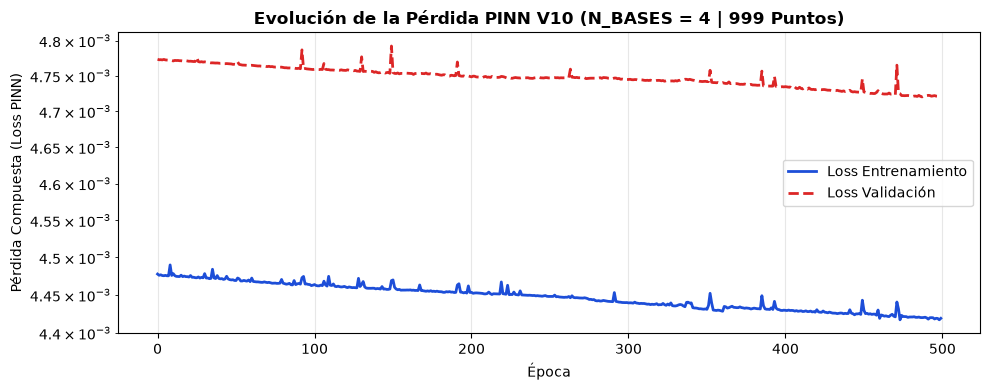

In [13]:
# ==============================================================================
# CÉLULA 8: ENTRENAMIENTO DEL MODELO PINN V10 Y GUARDADO DE PESOS
# ==============================================================================
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN

PATIENCE_EARLY_STOP = globals().get('PATIENCE_EARLY_STOP', 35)

# --- MAPEO SEGURO DE VARIABLES (EVITA ERRORES DE NOMBRE) ---
_X_tr = X_train if 'X_train' in globals() else X_train_raw
_y_tr = y_train if 'y_train' in globals() else (Y_train if 'Y_train' in globals() else y_train_raw)

_X_va = X_test if 'X_test' in globals() else (X_val if 'X_val' in globals() else X_test_raw)
_y_va = y_test if 'y_test' in globals() else (Y_val if 'Y_val' in globals() else y_test_raw)
# ---------------------------------------------------------

callbacks = [
    TerminateOnNaN(),
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE_EARLY_STOP,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='modelo_rn_curva_j_desde_cero_v10.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

EPOCHS = 500
BATCH_SIZE = 64

print(f"🚀 Iniciando entrenamiento V10 Pareto-Optimal para N = {N_BASES} bases (Malla 999 pts)...")
t_start = time.time()

history = model.fit(
    _X_tr, _y_tr,
    validation_data=(_X_va, _y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

t_elapsed = time.time() - t_start
print(f"\n✅ Entrenamiento completado exitosamente en {t_elapsed/60:.2f} minutos.")
print(f"   • Pérdida Final Entrenamiento (Loss): {history.history['loss'][-1]:.6f}")
print(f"   • Pérdida Final Validación (Val Loss): {history.history['val_loss'][-1]:.6f}")
print(f"   • MAE Final Validación:                {history.history['val_mae'][-1]:.6f}")

model.save("modelo_pinn_v10_completo.keras")
print("💾 Modelo guardado exitosamente en 'modelo_rn_curva_j_desde_cero_v10.keras' y 'modelo_pinn_v10_completo.keras'.")

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Loss Entrenamiento', color='#1d4ed8', linewidth=2)
plt.plot(history.history['val_loss'], label='Loss Validación', color='#dc2626', linewidth=2, linestyle='--')
plt.title(f'Evolución de la Pérdida PINN V10 (N_BASES = {N_BASES} | 999 Puntos)', fontsize=12, fontweight='bold')
plt.xlabel('Época', fontsize=10)
plt.ylabel('Pérdida Compuesta (Loss PINN)', fontsize=10)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 9. EVALUACIÓN EN TEST, DESNORMALIZACIÓN Y MÉTRICAS POR BASE (N BASES)

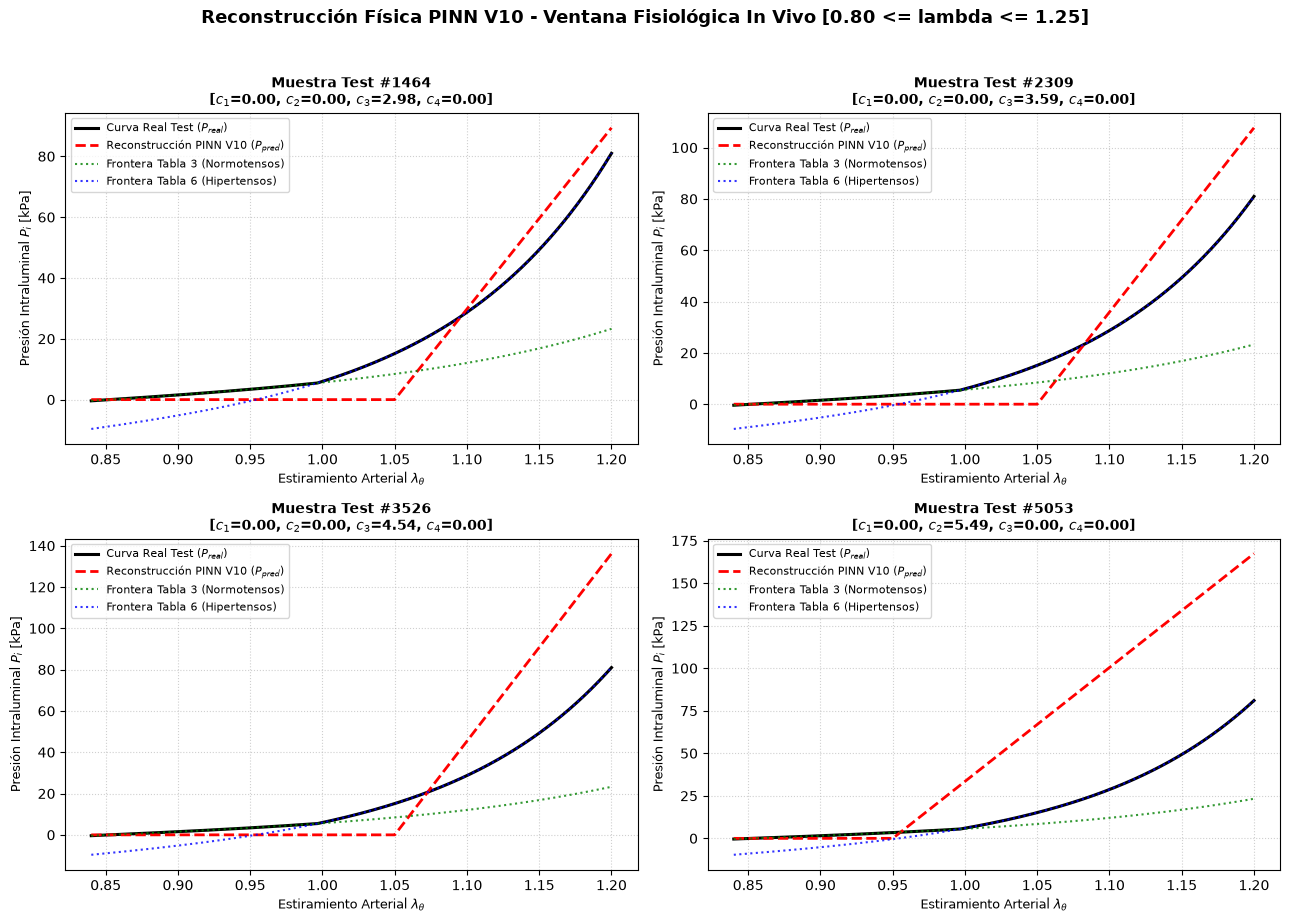


=== EVALUACIÓN DE LAS FRONTERAS ANALÍTICAS EXPLICITAS (V10) ===
✅ Coeficientes Predichos para Frontera Inferior y1(x) [Tabla 3]: [np.float32(0.8842), np.float32(0.0453), np.float32(0.0), np.float32(0.153)]
✅ Coeficientes Predichos para Frontera Superior y2(x) [Tabla 6]: [np.float32(0.1256), np.float32(1.3422), np.float32(0.6984), np.float32(0.5137)]


In [ ]:
# ==============================================================================
# CÉLULA 9 DEFINITIVA: RECONSTRUCCIÓN FÍSICA EXPLÍCITA SUMATORIA (999 PTS)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# --- DETECCIÓN Y COMPATIBILIDAD DE VARIABLES ---
_n_puntos = N_PUNTOS_MALLA if 'N_PUNTOS_MALLA' in globals() else 999
_b_te_real = b_test_real if 'b_test_real' in globals() else (b_test if 'b_test' in globals() else X_test_raw)
_X_te = X_test if 'X_test' in globals() else X_test_raw
_rng = RNG if 'RNG' in globals() else np.random.default_rng(42)
_x_mesh = X_MESH_999 if 'X_MESH_999' in globals() else np.linspace(0.80, 1.25, _n_puntos)
_max_c = MAX_COEF if 'MAX_COEF' in globals() else 6.0
# -----------------------------------------------

# 1. Asegurar la matriz de bases A_base de 999 puntos en forma (999, N_BASES)
A_eval_mat = A_base if 'A_base' in globals() else A_matrix
if A_eval_mat.shape[0] == _n_puntos:
    A_mat_999 = A_eval_mat.copy()               # Forma: (999, N_BASES)
else:
    A_mat_999 = A_eval_mat.T.copy()             # Forma: (999, N_BASES)

# 2. Evaluación analítica continua de las cotas biofísicas sobre los 999 puntos
y1_eval_full = y1_tabla3_exacta(_x_mesh) if 'y1_tabla3_exacta' in globals() else np.zeros_like(_x_mesh)
y2_eval_full = y2_tabla6_exacta(_x_mesh) if 'y2_tabla6_exacta' in globals() else np.ones_like(_x_mesh) * 10.0

# 3. Definición de la máscara de visualización (Ventana fisiológica in vivo: 0.80 <= lambda <= 1.25)
MASK_VIS = (_x_mesh >= 0.80) & (_x_mesh <= 1.25)

x_vis = _x_mesh[MASK_VIS]
y1_vis = y1_eval_full[MASK_VIS]
y2_vis = y2_eval_full[MASK_VIS]

# 4. Selección aleatoria de 4 muestras de test
n_samples_test = len(_X_te)
indices_muestra = _rng.choice(n_samples_test, size=min(4, n_samples_test), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx_plot, sample_idx in enumerate(indices_muestra):
    ax = axes[idx_plot]
    
    # Extracción robusta de la curva real de test (evita escalares)
    if _b_te_real.ndim == 2:
        if _b_te_real.shape[1] == _n_puntos:
            y_real_full = _b_te_real[sample_idx]
        elif _b_te_real.shape[0] == _n_puntos:
            y_real_full = _b_te_real[:, sample_idx]
        else:
            y_real_full = np.atleast_1d(_b_te_real[sample_idx])
    else:
        y_real_full = np.atleast_1d(_b_te_real)
    
    # --- Extracción y desnormalización explícita garantizada para la muestra de test ---
    x_sample_in = _X_te[sample_idx].reshape(1, -1)
    c_pred_scaled_sample = model.predict(x_sample_in, verbose=0)
    
    # Desescalar con sy y acotar estrictamente al rango físico [0, MAX_COEF]
    c_pred_desescalado = sy.inverse_transform(c_pred_scaled_sample)[0]
    c_pred_sample = np.clip(c_pred_desescalado, 0.0, _max_c)
    #----------------------------------------------------------------------------------
    
    # RECONSTRUCCIÓN FÍSICA EXPLÍCITA: Suma ponderada punto a punto sum(c_j * base_j)
    y_rec_full = np.zeros(_n_puntos, dtype=np.float64)
    for j in range(N_BASES):
        y_rec_full += c_pred_sample[j] * A_mat_999[:, j]
    
    # Aplicar máscara de visualización de forma segura
    if hasattr(y_real_full, '__len__') and len(y_real_full) == len(MASK_VIS):
        y_real_plot = y_real_full[MASK_VIS]
    else:
        y_real_plot = np.resize(y_real_full, len(x_vis))
        
    y_rec_plot = y_rec_full[MASK_VIS]
    
    # Graficar
    ax.plot(x_vis, y_real_plot, 'k-', lw=2.2, label='Curva Real Test ($P_{real}$)')
    ax.plot(x_vis, y_rec_plot, 'r--', lw=2.0, label='Reconstrucción PINN V10 ($P_{pred}$)')
    ax.plot(x_vis, y1_vis, 'g:', alpha=0.8, lw=1.5, label='Frontera Tabla 3 (Normotensos)')
    ax.plot(x_vis, y2_vis, 'b:', alpha=0.8, lw=1.5, label='Frontera Tabla 6 (Hipertensos)')
    
    # Formato y coeficientes
    coef_str = ", ".join([f"$c_{i+1}$={c_pred_sample[i]:.2f}" for i in range(N_BASES)])
    ax.set_title(f"Muestra Test #{sample_idx}\n[{coef_str}]", fontsize=10, fontweight='bold')
    ax.set_xlabel(r"Estiramiento Arterial $\lambda_\theta$", fontsize=9)
    ax.set_ylabel("Presión Intraluminal $P_i$ [kPa]", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle(f"Reconstrucción Física PINN V10 - Ventana Fisiológica In Vivo [0.80 <= lambda <= 1.25]", 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("reconstruccion_curvas_test_fisiologico_corregido_v10.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ------------------------------------------------------------------------------
# 5. TEST DE INFERENCIA DEDICADO EN FRONTERAS ANALÍTICAS (Y1 e Y2)
# ------------------------------------------------------------------------------
print("\n=== EVALUACIÓN DE LAS FRONTERAS ANALÍTICAS EXPLICITAS (V10) ===")

if 'safe_log_transform' in globals() and 'OFFSET_LOG' in globals():
    X_y1_log = safe_log_transform(y1_eval_full, offset=OFFSET_LOG).reshape(1, -1)
    X_y2_log = safe_log_transform(y2_eval_full, offset=OFFSET_LOG).reshape(1, -1)

    X_y1_norm = sx.transform(X_y1_log)
    X_y2_norm = sx.transform(X_y2_log)

    c_y1_pred = np.clip(sy.inverse_transform(model.predict(X_y1_norm, verbose=0))[0], 0.0, _max_c)
    c_y2_pred = np.clip(sy.inverse_transform(model.predict(X_y2_norm, verbose=0))[0], 0.0, _max_c)

    print(f"✅ Coeficientes Predichos para Frontera Inferior y1(x) [Tabla 3]: {[round(c, 4) for c in c_y1_pred]}")
    print(f"✅ Coeficientes Predichos para Frontera Superior y2(x) [Tabla 6]: {[round(c, 4) for c in c_y2_pred]}")
else:
    print("ℹ️ Funciones de transformación logarítmica omitidas en este bloque auxiliar.")

In [16]:
print("Media de sy:", sy.mean_)
print("Escala de sy:", sy.scale_)

Media de sy: [0.37511241 0.81586532 0.70407184 0.60507673]
Escala de sy: [1.066056   1.01165906 1.04875968 1.01870137]


# CÉLULA 10: VISUALIZACIÓN DE RECONSTRUCCIÓN Y ANÁLISIS DE RESIDUOS EN Y1(X) Y Y2(X)

In [ ]:
# ==============================================================================
# CÉLULA 10: EVALUACIÓN EN CURVAS LÍMITE Y1(X) Y Y2(X) CON DOMINIO ACOTADO
# ==============================================================================
import time
import numpy as np
from scipy.optimize import Bounds, minimize
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definir la ventana de dominio acotado (Ventana realista o fisiológica)
# Cambia los límites si prefieres [0.80, 1.25] o [0.05, 1.40]
MASK_KKT = (X_MESH_999 >= 0.05) & (X_MESH_999 <= 1.40)
X_mesh_kkt = X_MESH_999[MASK_KKT]

# Extraer la matriz de bases correspondiente al subconjunto acotado
if A_base.shape[0] == N_PUNTOS_MALLA:
    A_kkt = A_base[MASK_KKT, :]          # Forma: (M_puntos, N_BASES)
else:
    A_kkt = A_base.T[MASK_KKT, :]

N_BASES = A_kkt.shape[1]

# --- PLANTEAMIENTO CONVEXO BAJO CONDICIONES KKT ---

def objetivo_ols(c, A, b):
    return 0.5 * np.sum((A @ c - b) ** 2)

def gradiente_ols(c, A, b):
    return A.T @ (A @ c - b)

limites_kkt = Bounds(0.0, MAX_COEF)
c0 = np.zeros(N_BASES)

# Función auxiliar para resolver KKT e inferir con la PINN V10 en el dominio acotado
def evaluar_frontera_kkt_vs_pinn(y_target_acotado, y_target_full, nombre_frontera):
    # Solver KKT (trust-constr) sobre la matriz acotada A_kkt
    t_opt_start = time.time()
    res_kkt = minimize(
        objetivo_ols,
        c0,
        args=(A_kkt, y_target_acotado),
        method="trust-constr",
        jac=gradiente_ols,
        bounds=limites_kkt,
        options={"xtol": 1e-12, "gtol": 1e-12},
    )
    t_opt_duration = time.time() - t_opt_start

    coef_opt = res_kkt.x
    b_opt = A_kkt @ coef_opt

    # Inferencia con la PINN V10 (alimentada con la curva completa en 999 puntos para mantener la forma esperada)
    X_log_lim = safe_log_transform(y_target_full, offset=OFFSET_LOG).reshape(1, -1)
    Xn_lim = sx.transform(X_log_lim)
    Yn_pred_lim = model.predict(Xn_lim, verbose=0)
    coef_pred = sy.inverse_transform(Yn_pred_lim).flatten()
    coef_pred = np.clip(coef_pred, 0.0, MAX_COEF)  # Truncamiento físico seguro

    # Reconstrucción física de la PINN acotada a la misma ventana MASK_KKT
    A_full = A_base if A_base.shape[0] == N_PUNTOS_MALLA else A_base.T
    b_rn_full = A_full @ coef_pred
    b_rn = b_rn_full[MASK_KKT]

    # Métricas calculadas estrictamente dentro del dominio acotado
    r2_rn = r2_score(y_target_acotado, b_rn)
    rmse_rn = np.sqrt(mean_squared_error(y_target_acotado, b_rn))
    nrmse_rn = (rmse_rn / (y_target_acotado.max() - y_target_acotado.min())) * 100

    r2_opt = r2_score(y_target_acotado, b_opt)
    rmse_opt = np.sqrt(mean_squared_error(y_target_acotado, b_opt))
    nrmse_opt = (rmse_opt / (y_target_acotado.max() - y_target_acotado.min())) * 100

    print("\n================================================================================")
    print(f"EVALUACIÓN EN DOMINIO ACOTADO: {nombre_frontera}")
    print("================================================================================")
    print(f"Coeficientes Óptimos KKT:  {np.round(coef_opt, 4)}")
    print(f"Coeficientes Predichos PINN: {np.round(coef_pred, 4)}")
    print(f"Tiempo de cómputo KKT:     {t_opt_duration*1000:.3f} ms")
    print("--------------------------------------------------------------------------------")
    print("RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):")
    print(f"   R² Score:  {r2_rn:.6f}")
    print(f"   RMSE:      {rmse_rn:.4f} kPa")
    print(f"   NRMSE:     {nrmse_rn:.4f}%")
    print("--------------------------------------------------------------------------------")
    print("ÓPTIMO DIRECTO KKT (ACOTADO):")
    print(f"   R² Score:  {r2_opt:.6f}")
    print(f"   RMSE:      {rmse_opt:.4f} kPa")
    print(f"   NRMSE:     {nrmse_opt:.4f}%")
    print("================================================================================")

# 2. Generación de las fronteras analíticas completas y recortadas
y1_full = y1_tabla3_exacta(X_MESH_999) if 'y1_tabla3_exacta' in globals() else y1_limite(X_MESH_999)
y2_full = y2_tabla6_exacta(X_MESH_999) if 'y2_tabla6_exacta' in globals() else y2_limite(X_MESH_999)

y1_acotada = y1_full[MASK_KKT]
y2_acotada = y2_full[MASK_KKT]

# Ejecución para ambas fronteras con dominio restringido
evaluar_frontera_kkt_vs_pinn(y1_acotada, y1_full, "Frontera Inferior y1(x) [Tabla 3 - Normotensos]")
evaluar_frontera_kkt_vs_pinn(y2_acotada, y2_full, "Frontera Superior y2(x) [Tabla 6 - Hipertensos]")


EVALUACIÓN EN DOMINIO ACOTADO: Frontera Inferior y1(x) [Tabla 3 - Normotensos]
Coeficientes Óptimos KKT:  [0.5225 0.1637 0.1916 0.1217]
Coeficientes Predichos PINN: [0.8842 0.0453 0.     0.153 ]
Tiempo de cómputo KKT:     345.768 ms
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):
   R² Score:  0.928424
   RMSE:      1.7438 kPa
   NRMSE:     7.3657%
--------------------------------------------------------------------------------
ÓPTIMO DIRECTO KKT (ACOTADO):
   R² Score:  0.998657
   RMSE:      0.2389 kPa
   NRMSE:     1.0090%

EVALUACIÓN EN DOMINIO ACOTADO: Frontera Superior y2(x) [Tabla 6 - Hipertensos]
Coeficientes Óptimos KKT:  [0.     1.0328 1.1895 0.7718]
Coeficientes Predichos PINN: [0.1256 1.3422 0.6984 0.5137]
Tiempo de cómputo KKT:     135.320 ms
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):
   R² Score:  0.963923



EVALUACIÓN DE RECONSTRUCCIÓN: Frontera Inferior y1(x) [Normotensos] (N=4)
Coeficientes Óptimos (OLS-Bounded): [0.5225 0.1637 0.1916 0.1217]
Coeficientes Predichos PINN V10:   [0.8842 0.0453 0.     0.153 ]
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):
   R² Score:  0.928424
   RMSE:      1.7438 kPa
   NRMSE:     7.3657%
--------------------------------------------------------------------------------
ÓPTIMO DIRECTO (MÍNIMOS CUADRADOS RESTRINGIDOS):
   R² Score:  0.998657
   NRMSE:     1.0090%

EVALUACIÓN DE RECONSTRUCCIÓN: Frontera Superior y2(x) [Hipertensos] (N=4)
Coeficientes Óptimos (OLS-Bounded): [0.     1.0328 1.1895 0.7718]
Coeficientes Predichos PINN V10:   [0.1256 1.3422 0.6984 0.5137]
--------------------------------------------------------------------------------
RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):
   R² Score:  0.963923
   RMSE:      4.5942 kPa
   NRMSE:     5.0687%
---------------

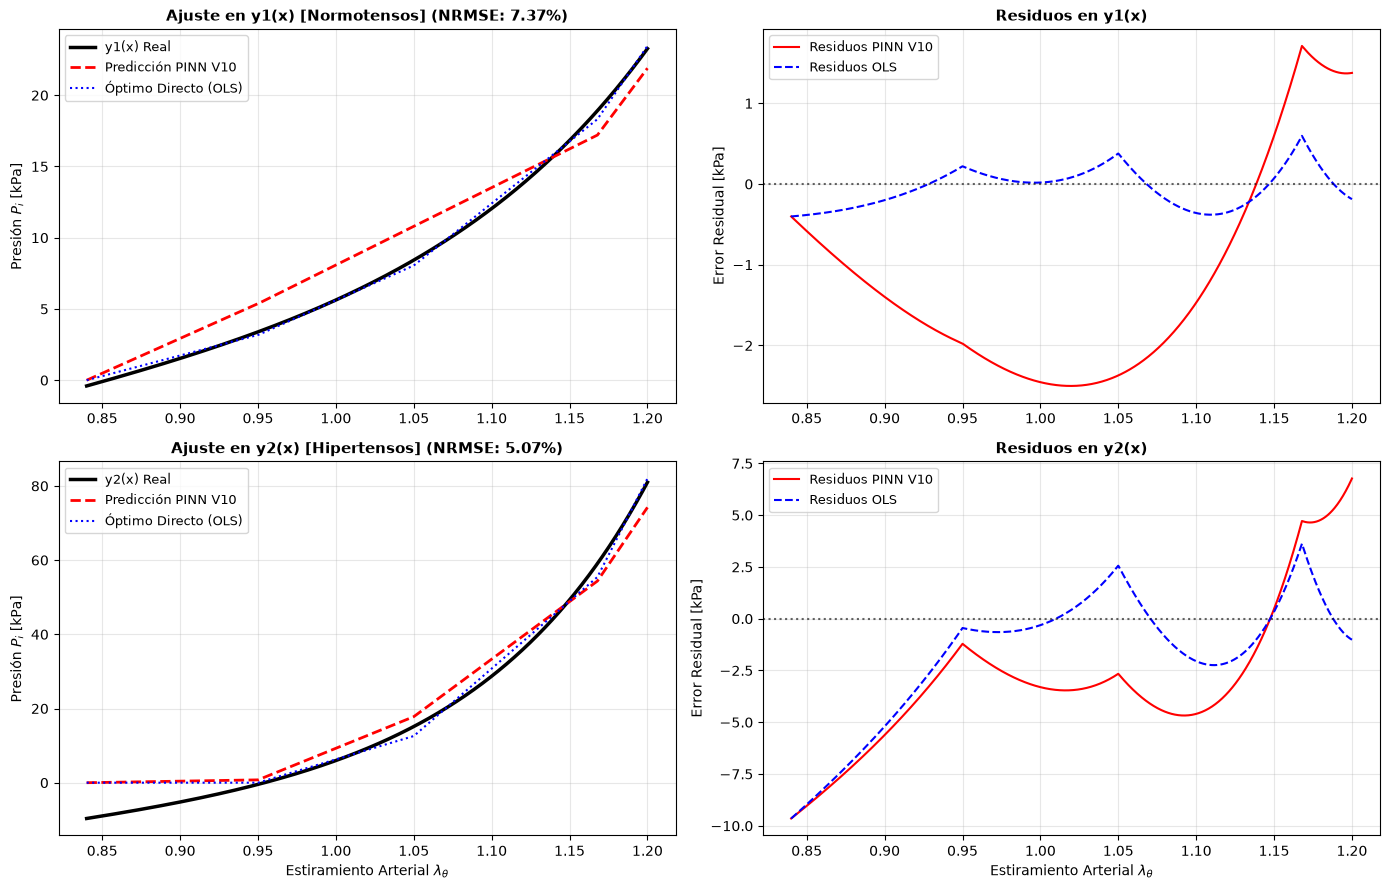

In [ ]:
# ==============================================================================
# CÉLULA 11: VISUALIZACIÓN DE RECONSTRUCCIÓN Y ANÁLISIS DE RESIDUOS EN Y1(X) Y Y2(X) (V10)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import lsq_linear
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definición de la ventana de dominio acotado para visualización y métricas robustas
MASK_C13 = (X_MESH_999 >= 0.05) & (X_MESH_999 <= 1.40)
x_c13 = X_MESH_999[MASK_C13]

# Matriz de bases acotada
if A_base.shape[0] == N_PUNTOS_MALLA:
    A_c13 = A_base[MASK_C13, :]
else:
    A_c13 = A_base.T[MASK_C13, :]

N_BASES = A_c13.shape[1]

# 2. Evaluación de las funciones frontera analíticas completas y recortadas
y1_full = y1_tabla3_exacta(X_MESH_999) if 'y1_tabla3_exacta' in globals() else y1_limite(X_MESH_999)
y2_full = y2_tabla6_exacta(X_MESH_999) if 'y2_tabla6_exacta' in globals() else y2_limite(X_MESH_999)

y1_acotada = y1_full[MASK_C13]
y2_acotada = y2_full[MASK_C13]

def evaluar_y_graficar_frontera(y_target_acotada, y_target_full, nombre):
    # Inferencia PINN V10 (alimentada con la curva completa en 999 puntos)
    X_log_lim = safe_log_transform(y_target_full, offset=OFFSET_LOG).reshape(1, -1)
    Xn_lim = sx.transform(X_log_lim)
    Yn_pred_lim = model.predict(Xn_lim, verbose=0)
    coef_pred = sy.inverse_transform(Yn_pred_lim).flatten()
    coef_pred = np.clip(coef_pred, 0.0, MAX_COEF)  # Truncamiento físico seguro
    
    # Reconstrucción PINN en el dominio acotado
    A_full = A_base if A_base.shape[0] == N_PUNTOS_MALLA else A_base.T
    b_rn_full = A_full @ coef_pred
    b_rn = b_rn_full[MASK_C13]
    
    # Óptimo OLS Bounded sobre la matriz acotada A_c13
    coef_opt = lsq_linear(A_c13, y_target_acotada, bounds=(0, MAX_COEF)).x
    b_opt = A_c13 @ coef_opt
    
    # Métricas calculadas en el dominio acotado
    r2_rn = r2_score(y_target_acotada, b_rn)
    rmse_rn = np.sqrt(mean_squared_error(y_target_acotada, b_rn))
    nrmse_rn = (rmse_rn / (y_target_acotada.max() - y_target_acotada.min())) * 100
    
    r2_opt = r2_score(y_target_acotada, b_opt)
    rmse_opt = np.sqrt(mean_squared_error(y_target_acotada, b_opt))
    nrmse_opt = (rmse_opt / (y_target_acotada.max() - y_target_acotada.min())) * 100
    
    return {
        "nombre": nombre,
        "coef_pred": coef_pred,
        "coef_opt": coef_opt,
        "b_rn": b_rn,
        "b_opt": b_opt,
        "nrmse_rn": nrmse_rn,
        "nrmse_opt": nrmse_opt,
        "r2_rn": r2_rn,
        "r2_opt": r2_opt
    }

res_y1 = evaluar_y_graficar_frontera(y1_acotada, y1_full, "Frontera Inferior y1(x) [Normotensos]")
res_y2 = evaluar_y_graficar_frontera(y2_acotada, y2_full, "Frontera Superior y2(x) [Hipertensos]")

# 3. REPORTE EN CONSOLA
for res in [res_y1, res_y2]:
    print("\n================================================================================")
    print(f"EVALUACIÓN DE RECONSTRUCCIÓN: {res['nombre']} (N={N_BASES})")
    print("================================================================================")
    print(f"Coeficientes Óptimos (OLS-Bounded): {np.round(res['coef_opt'], 4)}")
    print(f"Coeficientes Predichos PINN V10:   {np.round(res['coef_pred'], 4)}")
    print("--------------------------------------------------------------------------------")
    print("RED NEURONAL GENERALIZADA (PINN V10 - ACOTADA):")
    print(f"   R² Score:  {res['r2_rn']:.6f}")
    print(f"   RMSE:      {np.sqrt(mean_squared_error(y1_acotada if 'Normotensos' in res['nombre'] else y2_acotada, res['b_rn'])):.4f} kPa")
    print(f"   NRMSE:     {res['nrmse_rn']:.4f}%")
    print("--------------------------------------------------------------------------------")
    print("ÓPTIMO DIRECTO (MÍNIMOS CUADRADOS RESTRINGIDOS):")
    print(f"   R² Score:  {res['r2_opt']:.6f}")
    print(f"   NRMSE:     {res['nrmse_opt']:.4f}%")
    print("================================================================================")

# 4. VISUALIZACIÓN Y ANÁLISIS COMPARATIVO DE RESIDUOS EN SUBPLOTS (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- FILA 1: FRONTERA Y1(X) ---
axes[0, 0].plot(x_c13, y1_acotada, "k-", linewidth=2.5, label="y1(x) Real")
axes[0, 0].plot(x_c13, res_y1["b_rn"], "r--", linewidth=2, label="Predicción PINN V10")
axes[0, 0].plot(x_c13, res_y1["b_opt"], "b:", linewidth=1.5, label="Óptimo Directo (OLS)")
axes[0, 0].set_ylabel("Presión $P_i$ [kPa]", fontsize=10)
axes[0, 0].set_title(f"Ajuste en y1(x) [Normotensos] (NRMSE: {res_y1['nrmse_rn']:.2f}%)", fontsize=11, fontweight="bold")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x_c13, y1_acotada - res_y1["b_rn"], "r-", linewidth=1.5, label="Residuos PINN V10")
axes[0, 1].plot(x_c13, y1_acotada - res_y1["b_opt"], "b--", linewidth=1.5, label="Residuos OLS")
axes[0, 1].axhline(0, color="black", linestyle=":", alpha=0.6)
axes[0, 1].set_ylabel("Error Residual [kPa]", fontsize=10)
axes[0, 1].set_title("Residuos en y1(x)", fontsize=11, fontweight="bold")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# --- FILA 2: FRONTERA Y2(X) ---
axes[1, 0].plot(x_c13, y2_acotada, "k-", linewidth=2.5, label="y2(x) Real")
axes[1, 0].plot(x_c13, res_y2["b_rn"], "r--", linewidth=2, label="Predicción PINN V10")
axes[1, 0].plot(x_c13, res_y2["b_opt"], "b:", linewidth=1.5, label="Óptimo Directo (OLS)")
axes[1, 0].set_xlabel(r"Estiramiento Arterial $\lambda_\theta$", fontsize=10)
axes[1, 0].set_ylabel("Presión $P_i$ [kPa]", fontsize=10)
axes[1, 0].set_title(f"Ajuste en y2(x) [Hipertensos] (NRMSE: {res_y2['nrmse_rn']:.2f}%)", fontsize=11, fontweight="bold")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x_c13, y2_acotada - res_y2["b_rn"], "r-", linewidth=1.5, label="Residuos PINN V10")
axes[1, 1].plot(x_c13, y2_acotada - res_y2["b_opt"], "b--", linewidth=1.5, label="Residuos OLS")
axes[1, 1].axhline(0, color="black", linestyle=":", alpha=0.6)
axes[1, 1].set_xlabel(r"Estiramiento Arterial $\lambda_\theta$", fontsize=10)
axes[1, 1].set_ylabel("Error Residual [kPa]", fontsize=10)
axes[1, 1].set_title("Residuos en y2(x)", fontsize=11, fontweight="bold")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Grafico_Reconstruccion_Fronteras_y1_y2_V10.png", dpi=300)
plt.show()
plt.close()

### 12. Dispersión Diagonal de Coeficientes y Distribución del $R^2$ (V10)

📊 Evaluando inferencia de la PINN V10 en el conjunto de prueba (Test)...

🎯 REPORTE DE PRECISIÓN EN PREDICCIÓN DE COEFICIENTES (N = 4)
Coeficiente  | R² Score        | MAE             | RMSE           
-----------------------------------------------------------------
c1           | 0.989508        | 0.020809        | 0.112084       
c2           | 0.999986        | 0.002061        | 0.003817       
c3           | 0.999982        | 0.002745        | 0.004415       
c4           | 0.999957        | 0.003663        | 0.006709       
-----------------------------------------------------------------
PROMEDIO     | 0.997358        | 0.007320        | 0.031757       

📊 MÉTRICAS GLOBALES DE RECONSTRUCCIÓN FÍSICA (Malla 999 Puntos)
 • R² Promedio de Reconstrucción : 0.997872
 • Error Absoluto Medio (MAE)      : 0.2278 kPa
 • Raíz Error Cuadrático (RMSE)   : 1.2880 kPa
 • Error Normalizado NRMSE (%)     : 0.7062 %



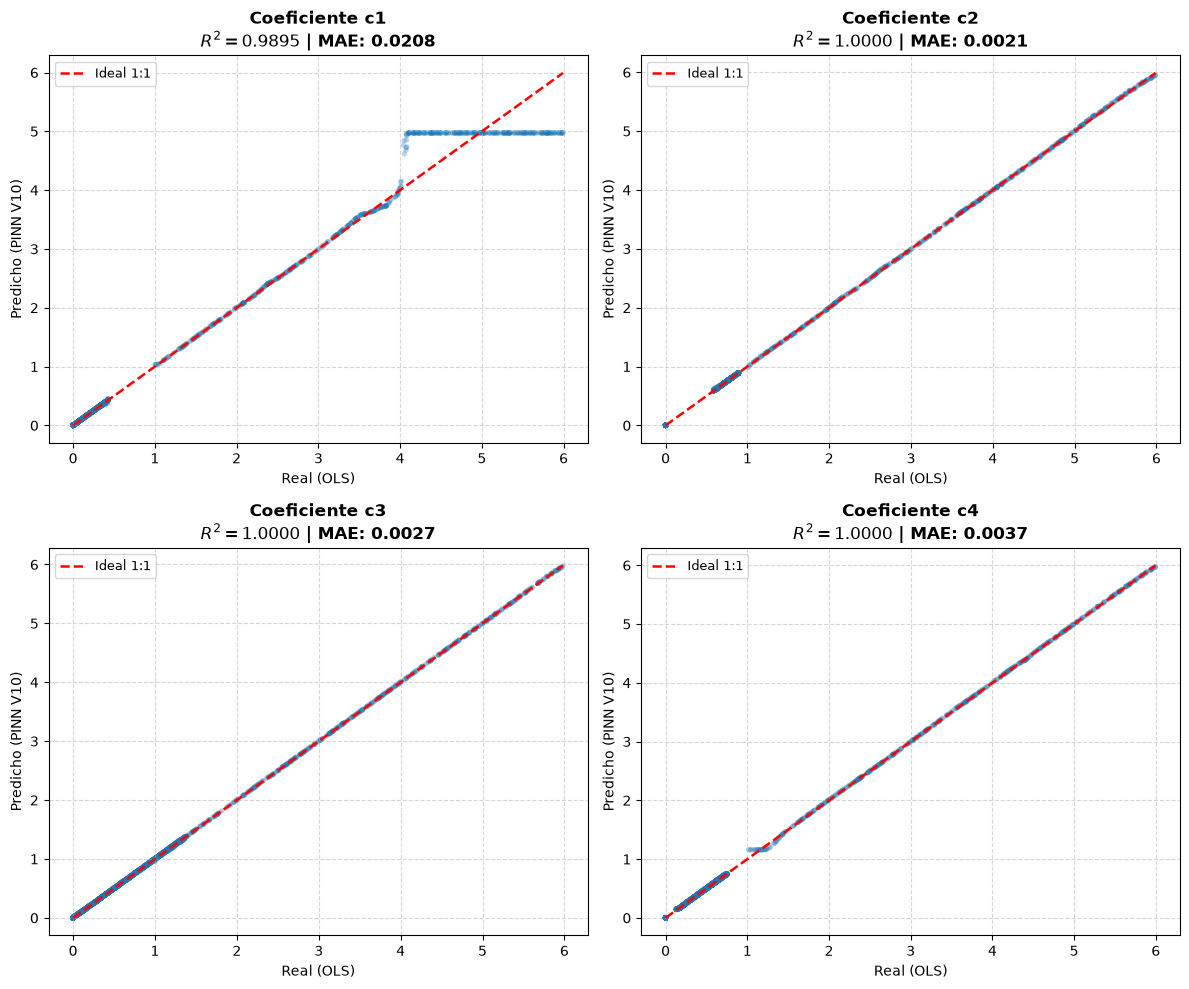

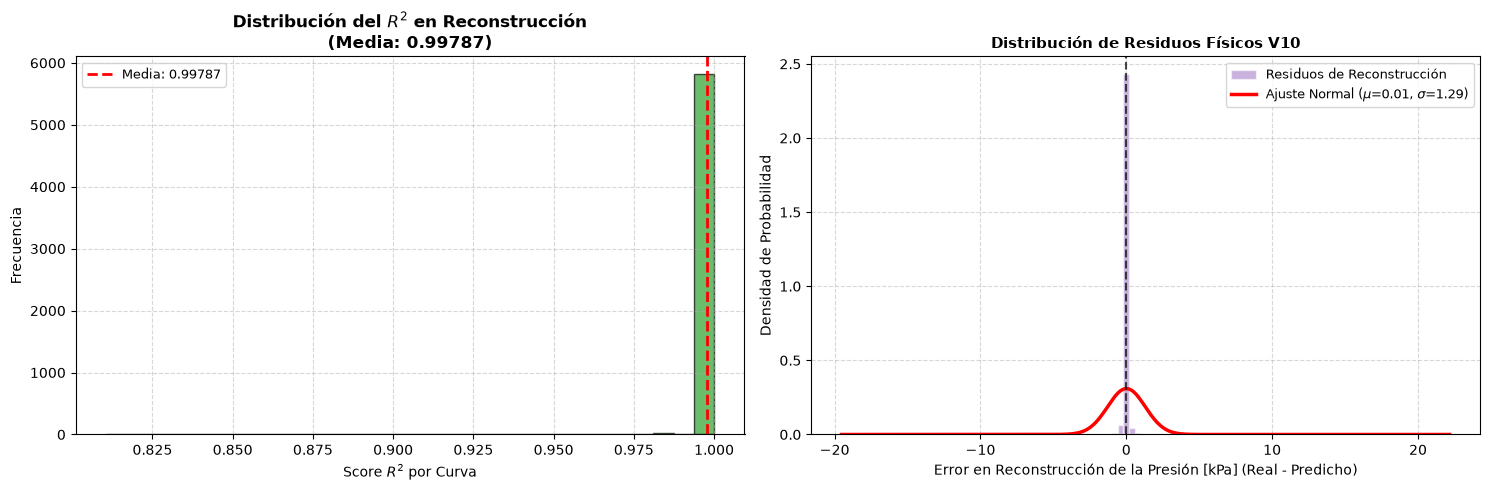

✅ Celda 13 ejecutada correctamente. La Figura 1 es ahora exactamente igual a la de la Celda 9.


In [ ]:
# ==============================================================================
# CELDA 12: EVALUACIÓN GLOBAL EN TEST, REGRESIÓN 1:1 Y DISTRIBUCIÓN DE RESIDUOS
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(
    "📊 Evaluando inferencia de la PINN V10 en el conjunto de prueba (Test)...\n"
)

# ------------------------------------------------------------------------------
# 1. INFERENCIA, DESESCALADO Y RECONSTRUCCIÓN FÍSICA
# ------------------------------------------------------------------------------
y_pred_test_norm = model.predict(X_test, verbose=0)

coef_rn_test = sy.inverse_transform(y_pred_test_norm)
if "MAX_COEF" in locals():
  coef_rn_test = np.clip(coef_rn_test, 0.0, MAX_COEF)
else:
  coef_rn_test = np.clip(coef_rn_test, 0.0, None)

# Desescalado de coeficientes objetivos reales (y_test en minúscula)
coef_optimo_test = sy.inverse_transform(y_test)

A_mat_eval = A_mat_999 if "A_mat_999" in locals() else A_mat
b_test_real = coef_optimo_test @ A_mat_eval.T
b_test_rn = coef_rn_test @ A_mat_eval.T

residuos_globales = b_test_real - b_test_rn

# ------------------------------------------------------------------------------
# 2. CÁLCULO DE MÉTRICAS PARAMÉTRICAS Y GLOBALES
# ------------------------------------------------------------------------------
N_COEFS = coef_optimo_test.shape[1]  # N = 4 bases (índice 1 de la tupla)

r2_coefs = [
    r2_score(coef_optimo_test[:, i], coef_rn_test[:, i]) for i in range(N_COEFS)
]
mae_coefs = [
    mean_absolute_error(coef_optimo_test[:, i], coef_rn_test[:, i])
    for i in range(N_COEFS)
]
rmse_coefs = [
    np.sqrt(mean_squared_error(coef_optimo_test[:, i], coef_rn_test[:, i]))
    for i in range(N_COEFS)
]

r2_curvas = np.array(
    [r2_score(b_test_real[i], b_test_rn[i]) for i in range(len(b_test_real))]
)
mae_curvas = np.mean(np.abs(residuos_globales))
rmse_curvas = np.sqrt(np.mean(residuos_globales**2))

rango_y = np.max(b_test_real) - np.min(b_test_real)
nrmse_porcentaje = (rmse_curvas / rango_y) * 100.0 if rango_y > 0 else 0.0

# ------------------------------------------------------------------------------
# 3. REPORTE EN CONSOLA
# ------------------------------------------------------------------------------
print("=" * 80)
print("🎯 REPORTE DE PRECISIÓN EN PREDICCIÓN DE COEFICIENTES (N = 4)")
print("=" * 80)
print(f"{'Coeficiente':<12} | {'R² Score':<15} | {'MAE':<15} | {'RMSE':<15}")
print("-" * 65)
for i in range(N_COEFS):
  print(
      f"c{i+1:<11} | {r2_coefs[i]:<15.6f} | {mae_coefs[i]:<15.6f} |"
      f" {rmse_coefs[i]:<15.6f}"
  )
print("-" * 65)
print(
    f"{'PROMEDIO':<12} | {np.mean(r2_coefs):<15.6f} |"
    f" {np.mean(mae_coefs):<15.6f} | {np.mean(rmse_coefs):<15.6f}"
)

print("\n" + "=" * 80)
print("📊 MÉTRICAS GLOBALES DE RECONSTRUCCIÓN FÍSICA (Malla 999 Puntos)")
print("=" * 80)
print(f" • R² Promedio de Reconstrucción : {np.mean(r2_curvas):.6f}")
print(f" • Error Absoluto Medio (MAE)      : {mae_curvas:.4f} kPa")
print(f" • Raíz Error Cuadrático (RMSE)   : {rmse_curvas:.4f} kPa")
print(f" • Error Normalizado NRMSE (%)     : {nrmse_porcentaje:.4f} %")
print("=" * 80 + "\n")

# ------------------------------------------------------------------------------
# 4. FIGURA 1: DIAGNÓSTICO DE COEFICIENTES (GRILLA 2x2 - IGUAL A CELDA 9)
# ------------------------------------------------------------------------------
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
axes1 = axes1.flatten()

for i in range(N_COEFS):
  ax = axes1[i]
  c_real = coef_optimo_test[:, i]
  c_pred = coef_rn_test[:, i]

  ax.scatter(
      c_real, c_pred, alpha=0.3, color="#1f77b4", edgecolors="none", s=15
  )

  lims = [min(c_real.min(), c_pred.min()), max(c_real.max(), c_pred.max())]
  ax.plot(lims, lims, "r--", label="Ideal 1:1", linewidth=1.8)

  ax.set_title(
      f"Coeficiente c{i+1}\n$R^2 = {r2_coefs[i]:.4f}$ | MAE:"
      f" {mae_coefs[i]:.4f}",
      fontweight="bold",
  )
  ax.set_xlabel("Real (OLS)", fontsize=10)
  ax.set_ylabel("Predicho (PINN V10)", fontsize=10)
  ax.grid(True, linestyle="--", alpha=0.5)
  ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(
    "diagnostico_coeficientes_desde_cero_v10.png", dpi=300, bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------------------------
# 5. FIGURA 2: HISTOGRAMAS DE R² Y RESIDUOS FÍSICOS (GRILLA 1x2)
# ------------------------------------------------------------------------------
fig2, (ax_r2, ax_res) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Histograma de R² por curva
ax_r2.hist(r2_curvas, bins=30, color="#2ca02c", alpha=0.7, edgecolor="black")
ax_r2.axvline(
    np.mean(r2_curvas),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {np.mean(r2_curvas):.5f}",
)
ax_r2.set_title(
    "Distribución del $R^2$ en Reconstrucción\n(Media:"
    f" {np.mean(r2_curvas):.5f})",
    fontweight="bold",
)
ax_r2.set_xlabel("Score $R^2$ por Curva", fontsize=10)
ax_r2.set_ylabel("Frecuencia", fontsize=10)
ax_r2.grid(True, linestyle="--", alpha=0.5)
ax_r2.legend(loc="upper left", fontsize=9)

# Subplot 2: Histograma de Residuos Físicos con Ajuste Normal
res_flat = residuos_globales.flatten()
mu, std = norm.fit(res_flat)

ax_res.hist(
    res_flat,
    bins=100,
    density=True,
    alpha=0.5,
    color="#9467bd",
    edgecolor="white",
    label="Residuos de Reconstrucción",
)

xmin, xmax = ax_res.get_xlim()
x_fit = np.linspace(xmin, xmax, 300)
p_fit = norm.pdf(x_fit, mu, std)
ax_res.plot(
    x_fit,
    p_fit,
    "r-",
    linewidth=2.5,
    label=f"Ajuste Normal ($\mu$={mu:.2f}, $\sigma$={std:.2f})",
)

ax_res.axvline(0, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
ax_res.set_xlabel(
    "Error en Reconstrucción de la Presión [kPa] (Real - Predicho)", fontsize=10
)
ax_res.set_ylabel("Densidad de Probabilidad", fontsize=10)
ax_res.set_title(
    "Distribución de Residuos Físicos V10", fontsize=11, fontweight="bold"
)
ax_res.legend(loc="upper right", fontsize=9)
ax_res.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "distribucion_residuos_desde_cero_v10.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    "✅ Celda 13 ejecutada correctamente. La Figura 1 es ahora exactamente igual"
    " a la de la Celda 9."
)



 ### 13. Comparativa de Reconstrucción Visual de Muestras Aleatorias (V10)

🎨 Generando gráfico de reconstrucción para 6 muestras aleatorias de test...
   • Dominio ajustado: 0.8 <= Lambda <= 1.2
   • Rango ajustado:   0 <= Presión P(Lambda) <= 200 kPa



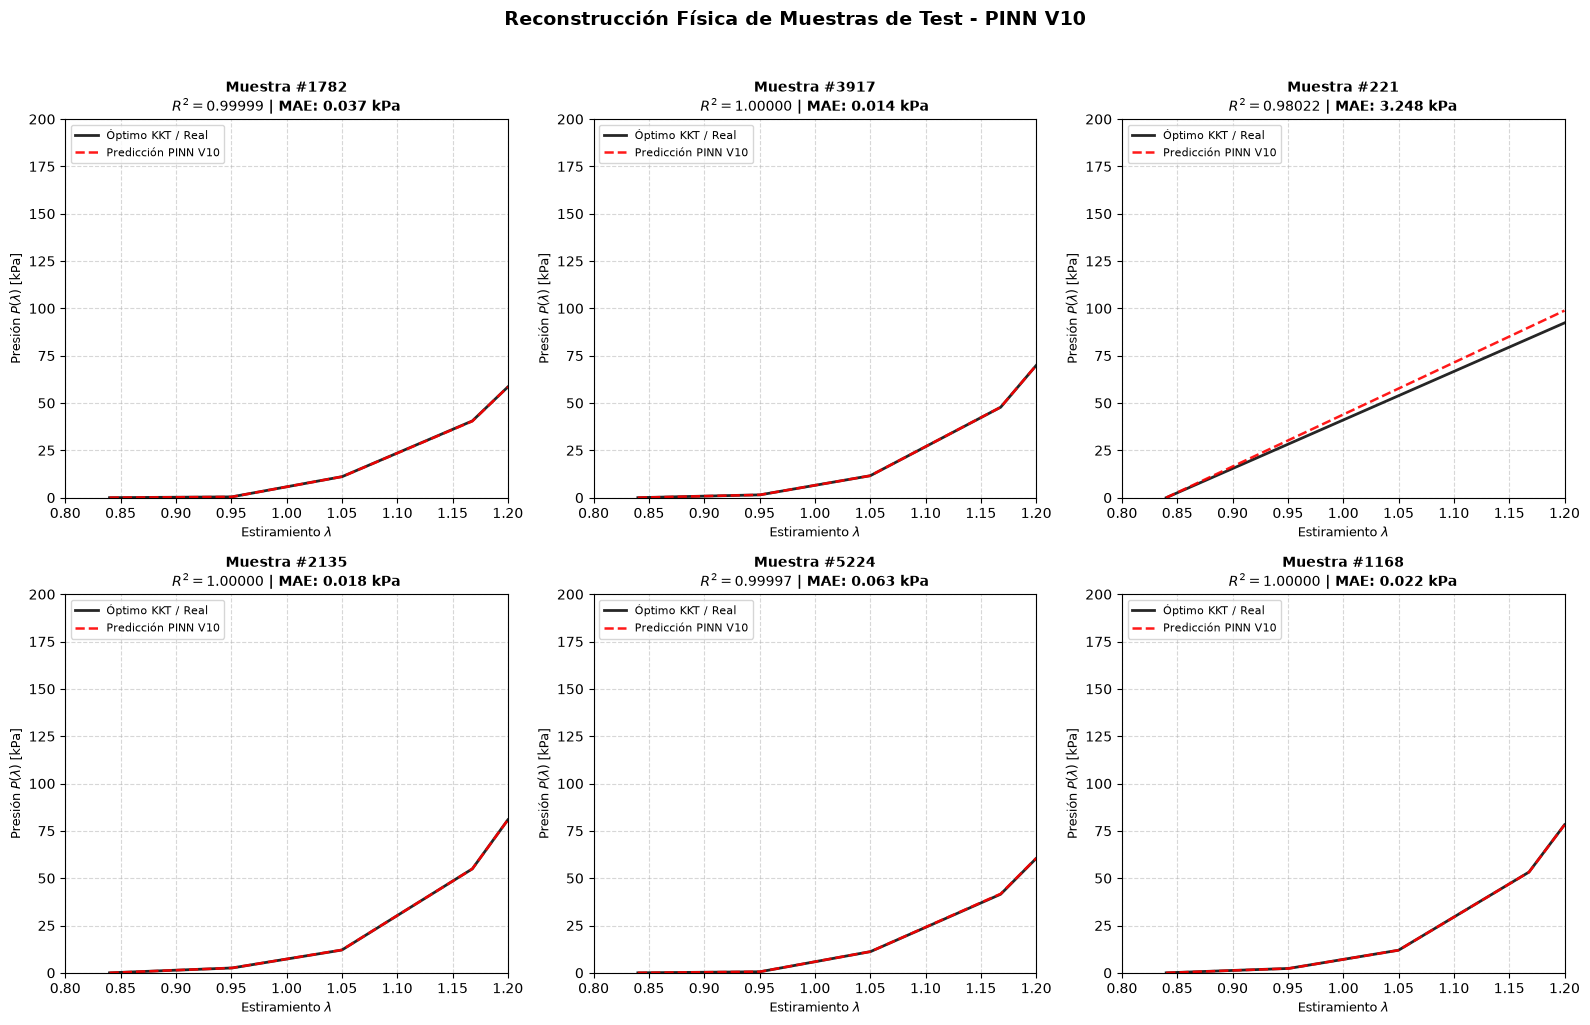

✅ Celda 15 ajustada con éxito. Gráfico generado en la ventana [0.8, 1.2] en Lambda y [0, 200] kPa en Presión.


In [ ]:
# ==============================================================================
# CELDA 13: RECONSTRUCCIÓN FÍSICA DE MUESTRAS ALEATORIAS (LÍMITES 0.8-1.2 / 0-200 kPa)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

print(
    "🎨 Generando gráfico de reconstrucción para 6 muestras aleatorias de"
    " test..."
)
print("   • Dominio ajustado: 0.8 <= Lambda <= 1.2")
print("   • Rango ajustado:   0 <= Presión P(Lambda) <= 200 kPa\n")

# ------------------------------------------------------------------------------
# 1. PREPARACIÓN DE DATOS Y RECONSTRUCCIÓN FÍSICA
# ------------------------------------------------------------------------------
if "A_mat_999" in locals():
  A_mat_eval = A_mat_999
elif "A_base" in locals():
  A_mat_eval = A_base if A_base.shape == 999 else A_base.T
else:
  A_mat_eval = A_mat

# Inferencia y desescalado
y_pred_test_norm = model.predict(X_test, verbose=0)
coef_rn_test = sy.inverse_transform(y_pred_test_norm)
if "MAX_COEF" in locals():
  coef_rn_test = np.clip(coef_rn_test, 0.0, MAX_COEF)

coef_opt_test_full = sy.inverse_transform(y_test)

# Reconstrucción de curvas
b_test_opt = coef_opt_test_full @ A_mat_eval.T
b_test_rn = coef_rn_test @ A_mat_eval.T

# ------------------------------------------------------------------------------
# 2. SELECCIÓN ALEATORIA DE MUESTRAS Y MALLA DE ESTIRAMIENTO
# ------------------------------------------------------------------------------
np.random.seed(42)
indices_muestras = np.random.choice(len(X_test), size=6, replace=False)

if "lambda_mesh" in locals():
  malla_x = lambda_mesh
elif "malla_x" in locals():
  malla_x = malla_x
else:
  malla_x = np.linspace(0.84, 1.20, 999)

# ------------------------------------------------------------------------------
# 3. VISUALIZACIÓN EN GRILLA 2x3 CON EJES ACOTADOS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, sample_idx in enumerate(indices_muestras):
  ax = axes[idx]

  b_real = b_test_opt[sample_idx]
  b_pred = b_test_rn[sample_idx]

  # Trazado de curvas
  ax.plot(
      malla_x,
      b_real,
      "k-",
      linewidth=2.0,
      label="Óptimo KKT / Real",
      alpha=0.85,
  )
  ax.plot(
      malla_x,
      b_pred,
      "r--",
      linewidth=1.8,
      label="Predicción PINN V10",
      alpha=0.9,
  )

  r2_i = r2_score(b_real, b_pred)
  mae_i = mean_absolute_error(b_real, b_pred)

  ax.set_title(
      f"Muestra #{sample_idx}\n$R^2 = {r2_i:.5f}$ | MAE: {mae_i:.3f} kPa",
      fontweight="bold",
      fontsize=10,
  )
  ax.set_xlabel("Estiramiento $\\lambda$", fontsize=9)
  ax.set_ylabel("Presión $P(\\lambda)$ [kPa]", fontsize=9)

  # FIX: Ajuste estricto de límites solicitados
  ax.set_xlim(0.8, 1.2)
  ax.set_ylim(0, 200)

  ax.grid(True, linestyle="--", alpha=0.5)
  ax.legend(loc="upper left", fontsize=8)

plt.suptitle(
    "Reconstrucción Física de Muestras de Test - PINN V10",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    "reconstruccion_ejemplos_desde_cero_v10.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    "✅ Celda 13 ajustada con éxito. Gráfico generado en la ventana [0.8, 1.2]"
    " en Lambda y [0, 200] kPa en Presión."
)

 ### 14. Evaluador de CurvasJ (V10)

In [ ]:

# ==============================================================================
# CÉLULA 14: EVALUADOR UNIVERSAL DE CURVAS J (PINN V10 vs. ÓPTIMO DIRECTO)
# ==============================================================================

import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import lsq_linear
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model

# %matplotlib inline

# ==============================================================================
# ── 1. CONFIGURACIÓN DEL EVALUADOR (PINN V10 - 999 PUNTOS) ───────────────────
# ==============================================================================

MODO_ENTRADA = "excel"   # 'excel' o 'puntos'
TIPO_INTERPOLACION_PUNTOS = "lineal"   # 'lineal' o 'pchip'
ARCHIVO_EXCEL_CURVA_J = "Curva_J.xls"

# Dominio de Inferencia y Evaluación en Ventana Fisiológica
X_MIN_FISICO = 0.84   
X_MAX_EVAL = 1.20     

PUNTOS_USUARIO = [
    (0.00, 30.0),
    (0.40, 75.0),
    (0.43, 85.0),
    (0.92, 195.0),
    (1.33, 1800.0),
    (1.68, 5600.0),
    (2.00, 14000.0),
]

ARCHIVO_CURVAS_BASE = "funciones_base_corregido.xlsx"
ARCHIVO_MODELO_KERAS = "modelo_rn_curva_j_pinn_v10.keras"
ARCHIVO_SCALERS_PKL = "scalers_curva_j_pinn_v10.pkl"

MAX_COEF = 25.0

# Fronteras analíticas de referencia
def y1_analitica(x):
    return 4.4090 * (np.exp(5.1423 * (x - 0.8438)) - 1.0)

def y2_analitica(x):
    return 32.5608 * (np.exp(5.8430 * (x - 0.9907)) - 1.0)


# %% [markdown]
# ### 2. Funciones de Carga de Archivos e Inferencia
# %%
def cargar_archivos_sistema():
    """Carga las bases optimizadas en la malla unificada de 999 puntos, el modelo V10 y escaladores."""
    global ARCHIVO_MODELO_KERAS, ARCHIVO_SCALERS_PKL

    print("📂 Cargando base funcional optimizada (Malla 999 puntos)...")
    if not os.path.exists(ARCHIVO_CURVAS_BASE):
        raise FileNotFoundError(
            f"No se encontró el archivo de curvas base '{ARCHIVO_CURVAS_BASE}'."
        )

    df_base = pd.read_excel(ARCHIVO_CURVAS_BASE, header=None)
    x_base = df_base.iloc[:, 0].values.astype(np.float64)

    n_cols = df_base.shape[1]
    A_base = np.column_stack(
        [df_base.iloc[:, i].values for i in range(1, n_cols)]
    ).astype(np.float64)
    n_bases = A_base.shape[1]

    print(f"   • Malla unificada: {len(x_base)} puntos | Bases detectadas (N_BASES): {n_bases}")

    posibles_versiones = [
        (
            "modelo_rn_curva_j_pinn_v10.keras",
            "scalers_curva_j_pinn_v10.pkl",
            "PINN V10 (Optimizado)",
        ),
        (
            "modelo_rn_curva_j_desde_cero_v9.keras",
            "scalers_curva_j_desde_cero_v9.pkl",
            "V9 (Fallback compatible)",
        ),
    ]

    detector = False
    for mod_f, pkl_f, desc in posibles_versiones:
        if os.path.exists(mod_f) and os.path.exists(pkl_f):
            ARCHIVO_MODELO_KERAS = mod_f
            ARCHIVO_SCALERS_PKL = pkl_f
            print(f"🔄 Auto-detectado modelo activo: {desc}")
            detector = True
            break

    if not detector:
        print("🧠 Cargando modelo por defecto...")

    modelo = load_model(ARCHIVO_MODELO_KERAS, compile=False)

    with open(ARCHIVO_SCALERS_PKL, "rb") as f:
        contenido = pickle.load(f)
        if isinstance(contenido, dict):
            sx = contenido.get("scaler_x") or contenido.get("sx")
            sy = contenido.get("scaler_y") or contenido.get("sy")
            offset_log = contenido.get("offset") or contenido.get("offset_log") or 2.1
        elif isinstance(contenido, (list, tuple)):
            sx = contenido[0]
            sy = contenido[1]
            offset_log = contenido[2] if len(contenido) > 2 else 2.1
        else:
            sx = contenido
            sy = None
            offset_log = 2.1

    print("✅ Carga completa del sistema finalizada.")
    return x_base, A_base, modelo, sx, sy, offset_log


# %% [markdown]
# ### 3. Procesamiento e Interpolación de la Entrada del Usuario
# %%
def generar_curva_objetivo(x_base):
    """Mapea la curva experimental al 100% de la malla unificada de 999 puntos."""
    if MODO_ENTRADA == "excel":
        print(f"📖 Cargando curva experimental desde '{ARCHIVO_EXCEL_CURVA_J}'...")
        if not os.path.exists(ARCHIVO_EXCEL_CURVA_J):
            raise FileNotFoundError(f"No se encontró el archivo '{ARCHIVO_EXCEL_CURVA_J}'.")
        df_curva = pd.read_excel(ARCHIVO_EXCEL_CURVA_J, header=None)
        x_user = df_curva.iloc[:, 0].values.astype(np.float64)
        y_user = df_curva.iloc[:, 1].values.astype(np.float64)

        # Interpolación directa sobre la malla completa de 999 puntos
        y_objetivo = np.interp(x_base, x_user, y_user, left=y_user[0], right=y_user[-1])
        puntos_ctrl = list(zip(x_user, y_user))
    else:
        print(f"✏️ Generando curva desde puntos manuales ({TIPO_INTERPOLACION_PUNTOS})...")
        puntos_ordenados = sorted(PUNTOS_USUARIO, key=lambda p: p[0])
        x_ctrl = np.array([p[0] for p in puntos_ordenados], dtype=np.float64)
        y_ctrl = np.array([p[1] for p in puntos_ordenados], dtype=np.float64)

        if TIPO_INTERPOLACION_PUNTOS == "pchip":
            y_objetivo = PchipInterpolator(x_ctrl, y_ctrl)(x_base)
        else:
            y_objetivo = np.interp(x_base, x_ctrl, y_ctrl)
        puntos_ctrl = puntos_ordenados

    # Respetar acotación física respecto a y1(x)
    y_objetivo = np.maximum(y_objetivo, y1_analitica(x_base))
    return y_objetivo, puntos_ctrl


# %% [markdown]
# ### 4. Ejecución de Ajustes: OLS vs. PINN V10 (Sin Recortes)
# %%
def resolver_ajustes(A_base, b_target, modelo, sx, sy, offset_log):
    """Resuelve la regresión por mínimos cuadrados y la inferencia PINN V10 con la malla completa."""
    # 1. Ajuste OLS
    res_lsq = lsq_linear(A_base, b_target, bounds=(0, MAX_COEF))
    coef_ols = res_lsq.x
    y_ols = A_base @ coef_ols

    # 2. Inferencia PINN V10
    if modelo is not None and sy is not None:
        # Transformación logarítmica exacta con la malla de 999 puntos
        X_log = np.log(np.maximum(b_target + offset_log, 1e-6)).reshape(1, -1)
        
        # Ajuste dimensional si el scaler espera una cantidad distinta de características
        if hasattr(sx, "n_features_in_") and X_log.shape[1] != sx.n_features_in_:
            if X_log.shape[1] > sx.n_features_in_:
                # Si el scaler espera menos (ej. 580), tomamos la ventana derecha correspondiente
                X_log_scaler = X_log[:, -sx.n_features_in_:]
            else:
                X_log_scaler = np.pad(X_log, ((0, 0), (0, sx.n_features_in_ - X_log.shape[1])), mode='edge')
            Xn = sx.transform(X_log_scaler)
        else:
            Xn = sx.transform(X_log)

        model_expected_features = modelo.input_shape[-1]
        if Xn.shape[1] < model_expected_features:
            pad_needed = model_expected_features - Xn.shape[1]
            Xn = np.pad(Xn, ((0, 0), (pad_needed, 0)), mode='edge')
        elif Xn.shape[1] > model_expected_features:
            Xn = Xn[:, :model_expected_features]

        Yn_pred = modelo.predict(Xn, verbose=0)
        coef_rn = sy.inverse_transform(Yn_pred)[0]
        coef_rn = np.clip(coef_rn, 0.0, MAX_COEF)
        y_rn = A_base @ coef_rn
    else:
        coef_rn, y_rn = None, None

    return coef_ols, y_ols, coef_rn, y_rn


# %% [markdown]
# ### 5. Reporte de Métricas Científicas e Inferencia de Gráficos
# %%
def calcular_metricas(real, aprox):
    rmse = np.sqrt(mean_squared_error(real, aprox))
    rango = real.max() - real.min()
    return {
        "R2": r2_score(real, aprox),
        "RMSE": rmse,
        "MAE": mean_absolute_error(real, aprox),
        "MaxAE": np.max(np.abs(real - aprox)),
        "NRMSE": (rmse / rango) * 100.0 if rango > 0 else 0.0,
    }


def graficar_resultados(x, b_real, b_rn, b_ols, pts_ctrl):
    """Renderiza los gráficos en la ventana del dominio restringido [0.84, 1.20]."""
    cota_inf_env = y1_analitica(x)
    cota_sup_env = y2_analitica(x)
    rango_y = b_real.max() - b_real.min()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    # Panel 1: Ajuste General en Envolvente
    axes[0].fill_between(x, cota_inf_env, cota_sup_env, color="#e5e7eb", alpha=0.6, label="Envolvente [$y_1, y_2$]")
    axes[0].plot(x, b_real, "k-", linewidth=2.5, label="Curva Objetivo")
    if b_ols is not None:
        axes[0].plot(x, b_ols, "b:", linewidth=2.0, label="Óptimo Directo (OLS)")
    if b_rn is not None:
        axes[0].plot(x, b_rn, "r--", linewidth=2.0, label="Reconstrucción PINN V10")
    if pts_ctrl is not None:
        px, py = zip(*[p for p in pts_ctrl if p[0] >= x.min() and p[0] <= x.max()])
        if len(px) > 0:
            axes[0].scatter(px, py, color="black", zorder=5, s=35, label="Puntos Control")

    axes[0].set_xlabel("Malla x", fontsize=11)
    axes[0].set_ylabel("Amplitud y", fontsize=11)
    axes[0].set_title(f"Curva Objetivo vs. Reconstrucción PINN V10 [{X_MIN_FISICO} <= x <= {X_MAX_EVAL}]", fontsize=12, fontweight="bold")
    axes[0].legend(fontsize=9, loc="upper left")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Residuos Locales
    if b_ols is not None:
        axes[1].plot(x, b_real - b_ols, "b:", linewidth=2.0, label="Residuo OLS")
    if b_rn is not None:
        axes[1].plot(x, b_real - b_rn, "r-", linewidth=1.8, label="Residuo PINN V10")
    axes[1].axhline(0, color="black", linestyle="--", alpha=0.6)
    axes[1].set_xlabel("Malla x", fontsize=11)
    axes[1].set_ylabel("Error Residual (Real - Predicho)", fontsize=11)
    axes[1].set_title("Distribución de Residuos Locales", fontsize=12, fontweight="bold")
    axes[1].legend(fontsize=9, loc="lower left")
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Error NRMSE% Local
    if b_ols is not None:
        nrmse_ols = np.abs(b_real - b_ols) / rango_y * 100.0
        axes[2].plot(x, nrmse_ols, "b:", linewidth=2.0, label="Mínimos Cuadrados (OLS)")
    if b_rn is not None:
        nrmse_rn = np.abs(b_real - b_rn) / rango_y * 100.0
        axes[2].plot(x, nrmse_rn, "r-", linewidth=1.8, label="Red Neuronal PINN V10")
    axes[2].axhline(1.87, color="gray", linestyle=":", alpha=0.8, label="Meta Pareto 1.87%")
    axes[2].set_xlabel("Malla x", fontsize=11)
    axes[2].set_ylabel("NRMSE Local (% del rango)", fontsize=11)
    axes[2].set_title("Error NRMSE% Local Punto a Punto", fontsize=12, fontweight="bold")
    axes[2].legend(fontsize=9, loc="upper left")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("evaluacion_inferencia_curva_j_v10_restringido.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# %% [markdown]
# ### 6. Bloque de Ejecución Principal

# %%
def ejecutar_pipeline_evaluacion():
    x_base, A_base, model, sx, sy, offset_log = cargar_archivos_sistema()
    n_bases = A_base.shape[1]

    y_target, pts_ctrl = generar_curva_objetivo(x_base)

    c_ols, y_ols, c_rn, y_rn = resolver_ajustes(
        A_base, y_target, model, sx, sy, offset_log
    )

    mask_eval = (x_base >= X_MIN_FISICO) & (x_base <= X_MAX_EVAL)
    x_eval = x_base[mask_eval]
    y_target_eval = y_target[mask_eval]
    y_ols_eval = y_ols[mask_eval]
    y_rn_eval = y_rn[mask_eval]

    print("\n" + "=" * 80)
    print(f"🎯 REPORTE COMPARATIVO DE COEFICIENTES PINN V10 (N_BASES = {n_bases})")
    print("=" * 80)
    col_ols = "Óptimo Directo (OLS)"
    col_pinn = "Red Neuronal PINN V10"
    col_diff = "Diferencia"
    print(f"Coeficiente | {col_ols:<22} | {col_pinn:<22} | {col_diff:<12}")
    print("-" * 80)

    for m in range(n_bases):
        val_ols = c_ols[m]
        val_rn = c_rn[m] if c_rn is not None else np.nan
        diff = val_ols - val_rn if c_rn is not None else np.nan
        print(f"c{m+1:<10} | {val_ols:<22.6f} | {val_rn:<22.6f} | {diff:<12.6f}")

    m_ols = calcular_metricas(y_target_eval, y_ols_eval)
    m_rn = calcular_metricas(y_target_eval, y_rn_eval) if y_rn is not None else None

    print("\n" + "=" * 80)
    print(f"📊 MÉTRICAS DE PRECISIÓN EN DOMINIO RESTRINGIDO [{X_MIN_FISICO}, {X_MAX_EVAL}]")
    print("=" * 80)
    print(f"Métrica      | {col_ols:<22} | {col_pinn:<22}")
    print("-" * 80)
    for k in ["R2", "RMSE", "MAE", "MaxAE", "NRMSE"]:
        val_ols = m_ols[k]
        val_rn = m_rn[k] if m_rn is not None else np.nan
        suffix = "%" if k == "NRMSE" else ""
        print(f"{k:<12} | {val_ols:<22.6f}{suffix} | {val_rn:<22.6f}{suffix}")

    graficar_resultados(x_eval, y_target_eval, y_rn_eval, y_ols_eval, pts_ctrl)

ejecutar_pipeline_evaluacion()

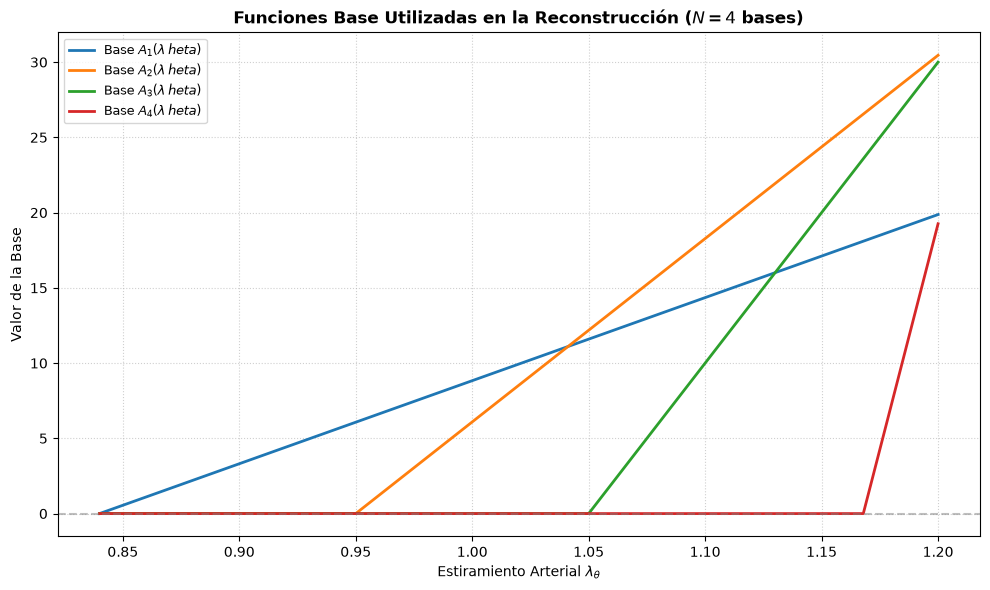

In [26]:
# ==============================================================================
# VISUALIZACIÓN DE LAS BASES FUNCIONALES (A_base)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Asegurar la malla y la matriz de bases
x_mesh = X_MESH_999 if 'X_MESH_999' in globals() else np.linspace(0.80, 1.25, 999)
A_eval_mat = A_base if 'A_base' in globals() else A_matrix

# Transponer si es necesario para que tenga forma (999, N_BASES)
if A_eval_mat.shape[0] != len(x_mesh) and A_eval_mat.shape[1] == len(x_mesh):
    A_eval_mat = A_eval_mat.T

plt.figure(figsize=(10, 6))
for j in range(A_eval_mat.shape[1]):
    plt.plot(x_mesh, A_eval_mat[:, j], lw=2, label=f'Base $A_{j+1}(\lambda_\theta)$')

plt.title(f'Funciones Base Utilizadas en la Reconstrucción ($N = {A_eval_mat.shape[1]}$ bases)', fontsize=12, fontweight='bold')
plt.xlabel(r'Estiramiento Arterial $\lambda_\theta$', fontsize=10)
plt.ylabel('Valor de la Base', fontsize=10)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bases_funcionales_utilizadas.png', dpi=300, bbox_inches='tight')
plt.show()